# Measuring arc spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# For intrinsic broadening
# J0021 merged specs in 4976

wcal_red = fits.open('/home/benjamin/Documents/pypeit18/redux_J0021/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')
wcal_blue = fits.open('/home/benjamin/Documents/pypeit18/redux_J0021/blue/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits')

# Two component model fit for [OIII] 4959

In [8]:
wcal_red.info()

Filename: /home/benjamin/Documents/pypeit18/redux_J0021/red/magellan_mage_A/Calibrations/WaveCalib_A_0_DET01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  SPAT_IDS      1 ImageHDU        26   (9,)   int64   
  2  SPAT_ID-558_WAVEFIT    1 BinTableHDU     40   1R x 6C   [104D, 104D, 104J, 2048D, 2048D, 121D]   
  3  SPAT_ID-558_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [104D, 104D, 1K, 104D, 5D, 104K]   
  4  SPAT_ID-624_WAVEFIT    1 BinTableHDU     40   1R x 6C   [101D, 101D, 101J, 2048D, 2048D, 124D]   
  5  SPAT_ID-624_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [101D, 101D, 1K, 101D, 5D, 101K]   
  6  SPAT_ID-685_WAVEFIT    1 BinTableHDU     40   1R x 6C   [102D, 102D, 102J, 2048D, 2048D, 133D]   
  7  SPAT_ID-685_PYPEITFIT    1 BinTableHDU     36   1R x 6C   [102D, 102D, 1K, 102D, 5D, 102K]   
  8  SPAT_ID-741_WAVEFIT    1 BinTableHDU     40   1R x 6C   [103D, 103D, 103J, 2048D, 2048D, 132D]   
  9  S

(0.0, 2000.0)

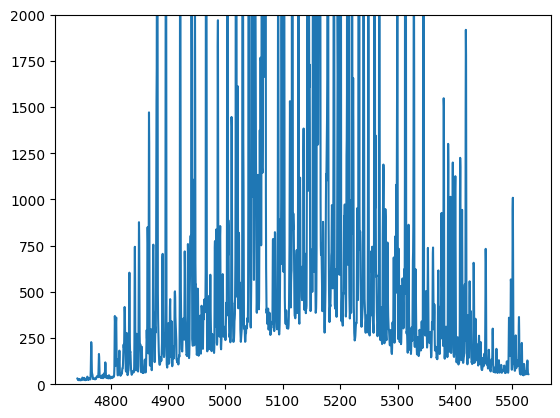

In [9]:
plt.plot(wcal_red[6].data['wave_soln'][0], wcal_red[21].data[:, 2])
#plt.xlim(4786, 4806)
plt.ylim(0, 2000)

# [OIII]4959

### Arc lines

In [10]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4959 = [wave_cat['[OIII]4959']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]4959']*(1 + z_BN[igal]) + 10]
mask_arc_4959 = (wcal_red[8].data['wave_soln'][0] >= wlims_4959[0]) & (wcal_red[8].data['wave_soln'][0] < wlims_4959[1])

# Arc spectra around the fitted line
x_arc_4959 = wcal_red[8].data['wave_soln'][0][mask_arc_4959]
y_arc_4959 = wcal_red[21].data[:, 3][mask_arc_4959]

100%|███████████████████████████████████████| 2500/2500 [00:31<00:00, 78.48it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 87.69633754  40.85882209  80.94711054 116.26560408  60.67675518
  44.22286837  70.37254163  68.28266931]


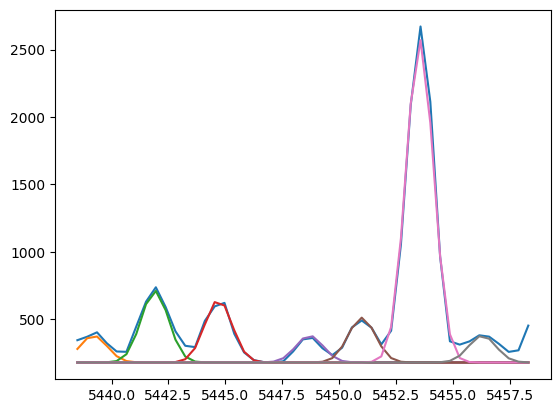

In [11]:
plt.plot(x_arc_4959, y_arc_4959)
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 300, 5439.2, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 800, 5441.9, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 700, 5444.7, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 300, 5448.7, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 500, 5451, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 3600, 5453.55, 0, 0.6))
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, 300, 5456.3, 0, 0.6))

params_arc_4959 = Parameters()
params_arc_4959.add('z', value=0.0, vary=False)
params_arc_4959.add('mu1', value=5439.2, vary=False)
params_arc_4959.add('mu2', value=5441.9, vary=False)
params_arc_4959.add('mu3', value=5444.7, vary=False)
params_arc_4959.add('mu4', value=5448.7, vary=False)
params_arc_4959.add('mu5', value=5451, vary=False)
params_arc_4959.add('mu6', value=5453.55, vary=False)
params_arc_4959.add('mu7', value=5456.3, vary=False)
params_arc_4959.add('arc1', value=300, min=0.)
params_arc_4959.add('arc2', value=800, min=0.)
params_arc_4959.add('arc3', value=700, min=0.)
params_arc_4959.add('arc4', value=300, min=0.)
params_arc_4959.add('arc5', value=500, min=0.)
params_arc_4959.add('arc6', value=3600, min=0.)
params_arc_4959.add('arc7', value=300, min=0.)
params_arc_4959.add('sigma', value=0.7, min=0.)
params_arc_4959.add('bkg', value=180, vary=False)

def residual_arc_4959(params_arc_4959, x, data, uncertainty):
    
    z = params_arc_4959['z']
    mu1 = params_arc_4959['mu1']
    mu2 = params_arc_4959['mu2']
    mu3 = params_arc_4959['mu3']
    mu4 = params_arc_4959['mu4']
    mu5 = params_arc_4959['mu5']
    mu6 = params_arc_4959['mu6']
    mu7 = params_arc_4959['mu7']
    flux1 = params_arc_4959['arc1']
    flux2 = params_arc_4959['arc2']
    flux3 = params_arc_4959['arc3']
    flux4 = params_arc_4959['arc4']
    flux5 = params_arc_4959['arc5']
    flux6 = params_arc_4959['arc6']
    flux7 = params_arc_4959['arc7']
    sigma = params_arc_4959['sigma']
    bkg = params_arc_4959['bkg']
    
    x = x_arc_4959
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model7 = gaussian(x, flux7, mu7, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6 + model7
    return (model - y_arc_4959) / 10

np.random.seed(21)
out_arc_4959 = minimize(residual_arc_4959, params_arc_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

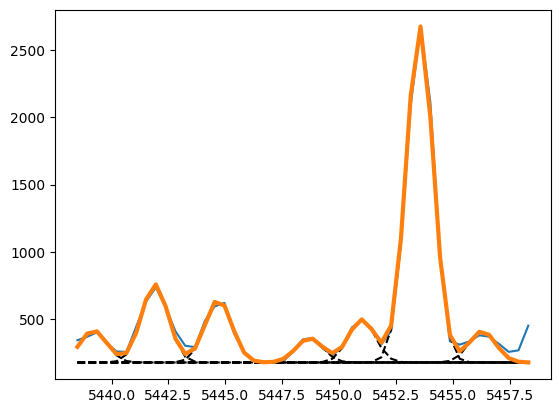

In [12]:
arc1_4959 = out_arc_4959.flatchain.arc1.mean()
arc2_4959 = out_arc_4959.flatchain.arc2.mean()
arc3_4959 = out_arc_4959.flatchain.arc3.mean()
arc4_4959 = out_arc_4959.flatchain.arc4.mean()
arc5_4959 = out_arc_4959.flatchain.arc5.mean()
arc6_4959 = out_arc_4959.flatchain.arc6.mean()
arc7_4959 = out_arc_4959.flatchain.arc7.mean()
sigma_arc_4959 = out_arc_4959.flatchain.sigma.mean()

plt.plot(x_arc_4959, y_arc_4959)

plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc1_4959, 5439.2, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc2_4959, 5441.9, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc3_4959, 5444.7, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc4_4959, 5448.7, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc5_4959, 5451, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc6_4959, 5453.55, 0, sigma_arc_4959), ls='--', color='black')
plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc7_4959, 5456.3, 0, sigma_arc_4959), ls='--', color='black')

plt.plot(x_arc_4959, 180 + gaussian(x_arc_4959, arc1_4959, 5439.2, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc2_4959, 5441.9, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc3_4959, 5444.7, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc4_4959, 5448.7, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc5_4959, 5451, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc6_4959, 5453.55, 0, sigma_arc_4959) \
         + gaussian(x_arc_4959, arc7_4959, 5456.3, 0, sigma_arc_4959), lw=3
)

---------

# [NII]6548 + H$\alpha$ + [NII]6584

### Arc lines

In [23]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_ha = [wave_cat['Ha']*(1 + z_BN[igal]) - 10, wave_cat['Ha']*(1 + z_BN[igal]) + 10]
mask_arc_ha = (wcal_red[12].data['wave_soln'][0] >= wlims_ha[0]) & (wcal_red[12].data['wave_soln'][0] < wlims_ha[1])

# Arc spectra around the fitted line
x_arc_ha = wcal_red[12].data['wave_soln'][0][mask_arc_ha]
y_arc_ha = wcal_red[21].data[:, 5][mask_arc_ha]

100%|███████████████████████████████████████| 2500/2500 [00:26<00:00, 93.28it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [91.41069451 50.79096291 75.65013989 86.51923111 19.68615736 66.6185604 ]


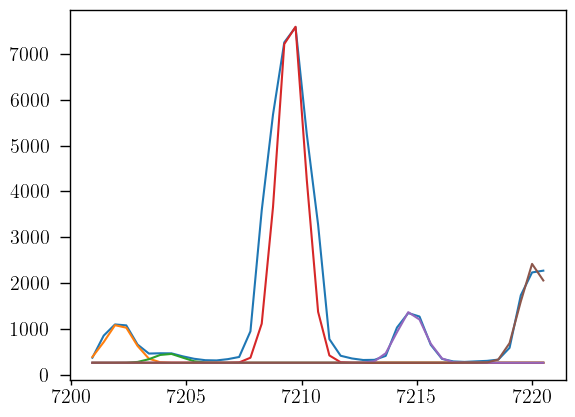

In [24]:
plt.plot(x_arc_ha, y_arc_ha)
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 1300, 7202.1, 0, 0.6))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 300, 7204.2, 0, 0.6))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 11700, 7209.53, 0, 0.6))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 1700, 7214.75, 0, 0.6))
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, 3300, 7220.1, 0, 0.6))

params_arc_ha = Parameters()
params_arc_ha.add('z', value=0.0, vary=False)
params_arc_ha.add('mu1', value=7202.1, vary=False)
params_arc_ha.add('mu2', value=7204.2, vary=False)
params_arc_ha.add('mu3', value=7209.53, vary=False)
params_arc_ha.add('mu4', value=7214.75, vary=False)
params_arc_ha.add('mu5', value=7220.1, vary=False)
params_arc_ha.add('arc1', value=1300, min=0.)
params_arc_ha.add('arc2', value=300, min=0.)
params_arc_ha.add('arc3', value=11700, min=0.)
params_arc_ha.add('arc4', value=1700, min=0.)
params_arc_ha.add('arc5', value=3300, min=0.)
params_arc_ha.add('sigma', value=0.6, min=0.)
params_arc_ha.add('bkg', value=260, vary=False)

def residual_arc_ha(params_arc_ha, x, data, uncertainty):
    
    z = params_arc_ha['z']
    mu1 = params_arc_ha['mu1']
    mu2 = params_arc_ha['mu2']
    mu3 = params_arc_ha['mu3']
    mu4 = params_arc_ha['mu4']
    mu5 = params_arc_ha['mu5']
    flux1 = params_arc_ha['arc1']
    flux2 = params_arc_ha['arc2']
    flux3 = params_arc_ha['arc3']
    flux4 = params_arc_ha['arc4']
    flux5 = params_arc_ha['arc5']
    sigma = params_arc_ha['sigma']
    bkg = params_arc_ha['bkg']
    
    x = x_arc_ha
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_ha) / 10

np.random.seed(21)
out_arc_ha = minimize(residual_arc_ha, params_arc_ha, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

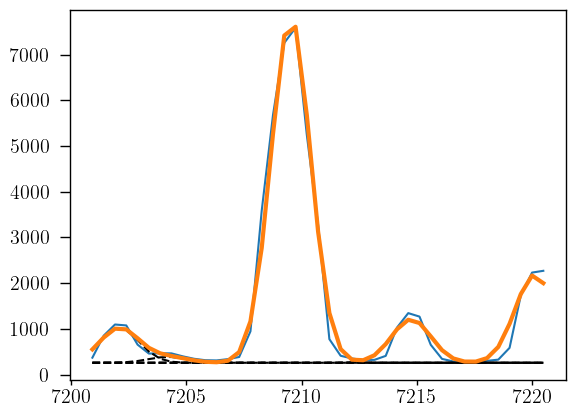

In [25]:
arc1_ha = out_arc_ha.flatchain.arc1.mean()
arc2_ha = out_arc_ha.flatchain.arc2.mean()
arc3_ha = out_arc_ha.flatchain.arc3.mean()
arc4_ha = out_arc_ha.flatchain.arc4.mean()
arc5_ha = out_arc_ha.flatchain.arc5.mean()
sigma_arc_ha = out_arc_ha.flatchain.sigma.mean()

plt.plot(x_arc_ha, y_arc_ha)

plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc1_ha, 7202.1, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc2_ha, 7204.2, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc3_ha, 7209.53, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc4_ha, 7214.75, 0, sigma_arc_ha), ls='--', color='black')
plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc5_ha, 7220.1, 0, sigma_arc_ha), ls='--', color='black')

plt.plot(x_arc_ha, 260 + gaussian(x_arc_ha, arc1_ha, 7202.1, 0, sigma_arc_ha) \
         + gaussian(x_arc_ha, arc2_ha, 7204.2, 0, sigma_arc_ha) \
         + gaussian(x_arc_ha, arc3_ha, 7209.53, 0, sigma_arc_ha) \
         + gaussian(x_arc_ha, arc4_ha, 7214.75, 0, sigma_arc_ha) \
         + gaussian(x_arc_ha, arc5_ha, 7220.1, 0, sigma_arc_ha), lw=3
)

# [OII]7319 + [OII]7330

### Arc lines

In [33]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7330 = [wave_cat['[OII]7330']*(1 + z_BN[igal]) - 10, wave_cat['[OII]7330']*(1 + z_BN[igal]) + 10]
mask_arc_7330 = (wcal_red[14].data['wave_soln'][0] >= wlims_7330[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_7330[1])

# Arc spectra around the fitted line
x_arc_7330 = wcal_red[14].data['wave_soln'][0][mask_arc_7330]
y_arc_7330 = wcal_red[21].data[:, 6][mask_arc_7330]

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 123.48it/s]


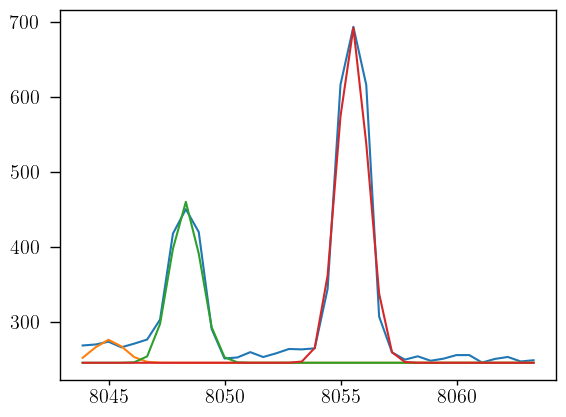

In [34]:
plt.plot(x_arc_7330, y_arc_7330)
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, 50, 8045, 0, 0.65))
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, 350, 8048.3, 0, 0.65))
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, 730, 8055.5, 0, 0.65))

params_arc_7330 = Parameters()
params_arc_7330.add('z', value=0.0, vary=False)
params_arc_7330.add('mu1', value=8045, vary=False)
params_arc_7330.add('mu2', value=8048.3, vary=False)
params_arc_7330.add('mu3', value=8055.5, vary=False)
params_arc_7330.add('arc1', value=50, min=0.)
params_arc_7330.add('arc2', value=350, min=0.)
params_arc_7330.add('arc3', value=730, min=0.)
params_arc_7330.add('sigma', value=0.65, min=0.)
params_arc_7330.add('bkg', value=245, vary=False)

def residual_arc_7330(params_arc_7330, x, data, uncertainty):
    
    z = params_arc_7330['z']
    mu1 = params_arc_7330['mu1']
    mu2 = params_arc_7330['mu2']
    mu3 = params_arc_7330['mu3']
    flux1 = params_arc_7330['arc1']
    flux2 = params_arc_7330['arc2']
    flux3 = params_arc_7330['arc3']
    sigma = params_arc_7330['sigma']
    bkg = params_arc_7330['bkg']
    
    x = x_arc_7330
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_7330) / 10

np.random.seed(21)
out_arc_7330 = minimize(residual_arc_7330, params_arc_7330, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

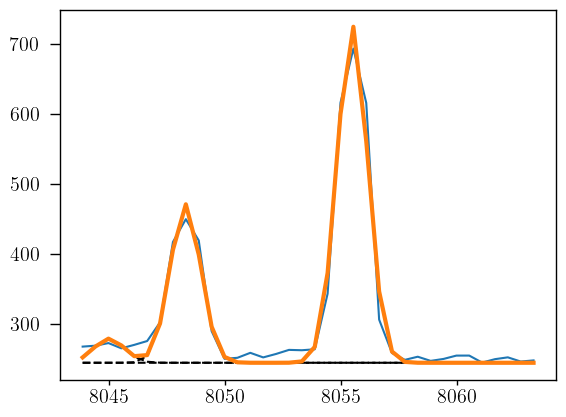

In [35]:
arc1_7330 = out_arc_7330.flatchain.arc1.mean()
arc2_7330 = out_arc_7330.flatchain.arc2.mean()
arc3_7330 = out_arc_7330.flatchain.arc3.mean()
sigma_arc_7330 = out_arc_7330.flatchain.sigma.mean()

plt.plot(x_arc_7330, y_arc_7330)

plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, arc1_7330, 8045, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, arc2_7330, 8048.3, 0, sigma_arc_7330), ls='--', color='black')
plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, arc3_7330, 8055.5, 0, sigma_arc_7330), ls='--', color='black')

plt.plot(x_arc_7330, 245 + gaussian(x_arc_7330, arc1_7330, 8045, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc2_7330, 8048.3, 0, sigma_arc_7330) \
         + gaussian(x_arc_7330, arc3_7330, 8055.5, 0, sigma_arc_7330), lw=3
)

# HeI 7065

### Arc lines

In [45]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7065 = [wave_cat['HeI7065']*(1 + z_BN[igal]) + 5, wave_cat['HeI7065']*(1 + z_BN[igal]) + 20]
mask_arc_7065 = (wcal_red[14].data['wave_soln'][0] >= wlims_7065[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_7065[1])

# Arc spectra around the fitted line
x_arc_7065 = wcal_red[14].data['wave_soln'][0][mask_arc_7065]
y_arc_7065 = wcal_red[21].data[:, 6][mask_arc_7065]

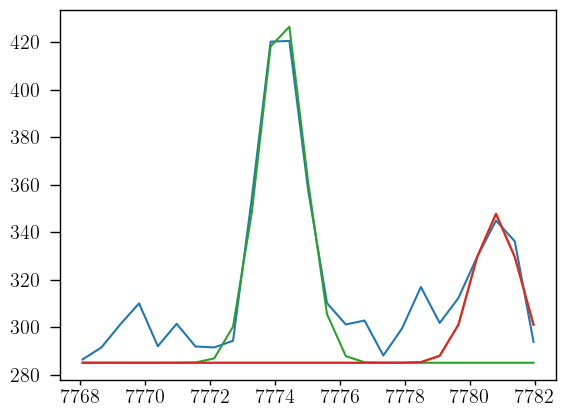

In [46]:
plt.plot(x_arc_7065, y_arc_7065)
plt.plot(x_arc_7065, 285 + gaussian(x_arc_7065, 110, 7780.8, 0, 0.7))
plt.plot(x_arc_7065, 285 + gaussian(x_arc_7065, 263, 7774.2, 0, 0.7))
plt.plot(x_arc_7065, 285 + gaussian(x_arc_7065, 110, 7780.8, 0, 0.7))

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 146.68it/s]


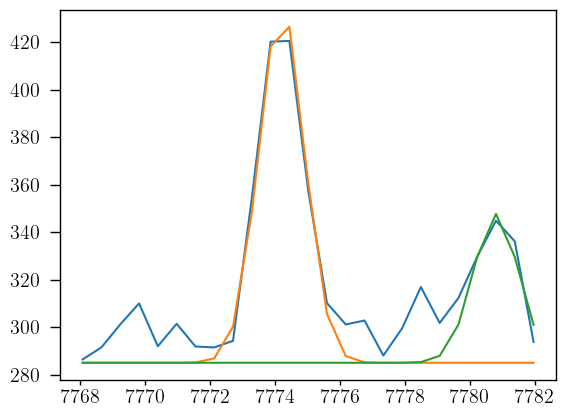

In [47]:
plt.plot(x_arc_7065, y_arc_7065)
plt.plot(x_arc_7065, 285 + gaussian(x_arc_7065, 263, 7774.2, 0, 0.7))
plt.plot(x_arc_7065, 285 + gaussian(x_arc_7065, 110, 7780.8, 0, 0.7))

params_arc_7065 = Parameters()
params_arc_7065.add('z', value=0.0, vary=False)
params_arc_7065.add('mu1', value=7774.2, vary=False)
params_arc_7065.add('mu2', value=7780.8, vary=False)
params_arc_7065.add('arc1', value=263, min=0.)
params_arc_7065.add('arc2', value=110, min=0.)
params_arc_7065.add('sigma', value=0.7, min=0.)
params_arc_7065.add('bkg', value=285, vary=False)

def residual_arc_7065(params_arc_7065, x, data, uncertainty):
    
    z = params_arc_7065['z']
    mu1 = params_arc_7065['mu1']
    mu2 = params_arc_7065['mu2']
    flux1 = params_arc_7065['arc1']
    flux2 = params_arc_7065['arc2']
    sigma = params_arc_7065['sigma']
    bkg = params_arc_7065['bkg']
    
    x = x_arc_7065
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_7065) / 10

np.random.seed(21)
out_arc_7065 = minimize(residual_arc_7065, params_arc_7065, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [48]:
out_arc_7065.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7774.20000,,,7774.2,-inf,inf,False
mu2,7780.80000,,,7780.8,-inf,inf,False
arc1,269.701597,14.9868475,(5.56%),263,0.00000000,inf,True
arc2,117.784152,13.3457162,(11.33%),110,0.00000000,inf,True
sigma,0.75319901,0.04923047,(6.54%),0.7,0.00000000,inf,True
bkg,285.000000,,,285,-inf,inf,False


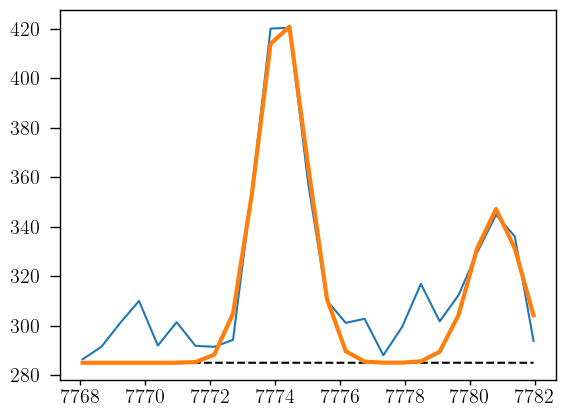

In [49]:
arc1_7065 = out_arc_7065.flatchain.arc1.mean()
arc2_7065 = out_arc_7065.flatchain.arc2.mean()
sigma_arc_7065 = out_arc_7065.flatchain.sigma.mean()

plt.plot(x_arc_7065, y_arc_7065)

plt.plot(x_arc_7065, 285 + gaussian(x_arc_7065, arc1_7065, 7774.2, 0, sigma_arc_7065), ls='--', color='black')
plt.plot(x_arc_7065, 285 + gaussian(x_arc_7065, arc2_7065, 7780.8, 0, sigma_arc_7065), ls='--', color='black')

plt.plot(x_arc_7065, 285 + gaussian(x_arc_7065, arc1_7065, 7774.2, 0, sigma_arc_7065) \
         + gaussian(x_arc_7065, arc2_7065, 7780.8, 0, sigma_arc_7065), lw=3
)

# HeI 6678

### Arc lines

In [58]:
wave_cat['HeI6678']*(1 + z_BN[igal])

7337.2845037

In [59]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6678 = [wave_cat['HeI6678']*(1 + z_BN[igal]) - 10, wave_cat['HeI6678']*(1 + z_BN[igal]) + 10]
mask_arc_6678 = (wcal_red[14].data['wave_soln'][0] >= wlims_6678[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_6678[1])

# Arc spectra around the fitted line
x_arc_6678 = wcal_red[14].data['wave_soln'][0][mask_arc_6678]
y_arc_6678 = wcal_red[21].data[:, 6][mask_arc_6678]

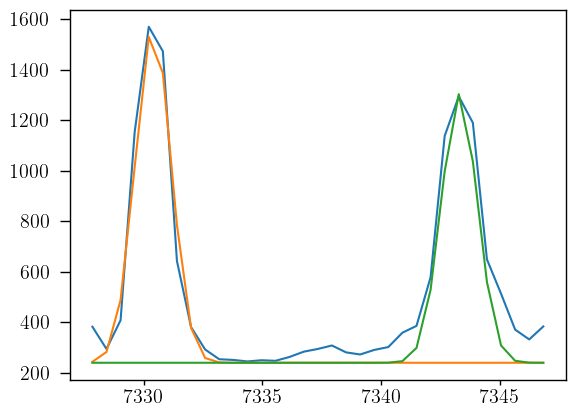

In [60]:
plt.plot(x_arc_6678, y_arc_6678)
plt.plot(x_arc_6678, 240 + gaussian(x_arc_6678, 2500, 7330.4, 0, 0.75))
plt.plot(x_arc_6678, 240 + gaussian(x_arc_6678, 2000, 7343.3, 0, 0.75))

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 144.48it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [49.34964714 58.67753217 55.29819442]


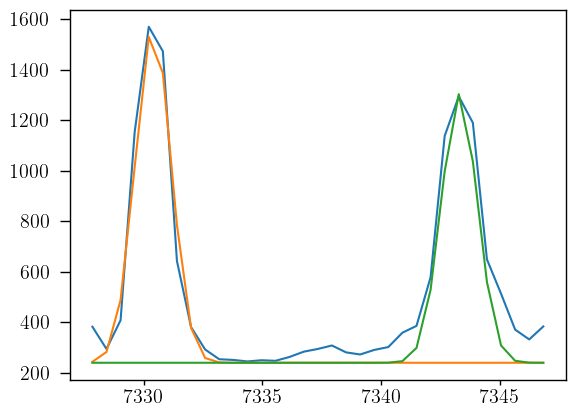

In [61]:
plt.plot(x_arc_6678, y_arc_6678)
plt.plot(x_arc_6678, 240 + gaussian(x_arc_6678, 2500, 7330.4, 0, 0.75))
plt.plot(x_arc_6678, 240 + gaussian(x_arc_6678, 2000, 7343.3, 0, 0.75))

params_arc_6678 = Parameters()
params_arc_6678.add('z', value=0.0, vary=False)
params_arc_6678.add('mu1', value=7330.4, vary=False)
params_arc_6678.add('mu2', value=7343.3, vary=False)
params_arc_6678.add('arc1', value=2500, min=0.)
params_arc_6678.add('arc2', value=2000, min=0.)
params_arc_6678.add('sigma', value=0.75, min=0.)
params_arc_6678.add('bkg', value=240, vary=False)

def residual_arc_6678(params_arc_6678, x, data, uncertainty):
    
    z = params_arc_6678['z']
    mu1 = params_arc_6678['mu1']
    mu2 = params_arc_6678['mu2']
    flux1 = params_arc_6678['arc1']
    flux2 = params_arc_6678['arc2']
    sigma = params_arc_6678['sigma']
    bkg = params_arc_6678['bkg']
    
    x = x_arc_6678
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_6678) / 10

np.random.seed(21)
out_arc_6678 = minimize(residual_arc_6678, params_arc_6678, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [62]:
out_arc_6678.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7330.40000,,,7330.4,-inf,inf,False
mu2,7343.30000,,,7343.3,-inf,inf,False
arc1,2650.35297,14.3420168,(0.54%),2500,0.00000000,inf,True
arc2,2274.05719,14.9529088,(0.66%),2000,0.00000000,inf,True
sigma,0.78030492,0.00435709,(0.56%),0.75,0.00000000,inf,True
bkg,240.000000,,,240,-inf,inf,False


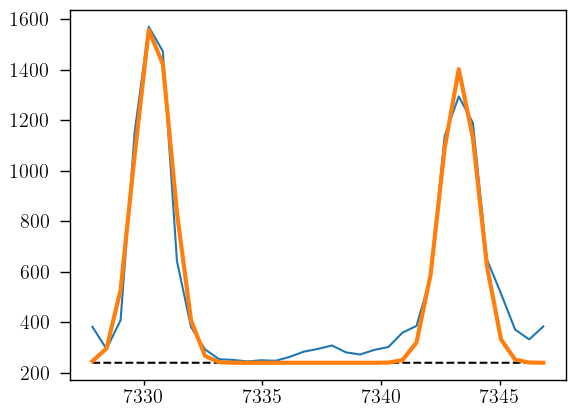

In [63]:
arc1_6678 = out_arc_6678.flatchain.arc1.mean()
arc2_6678 = out_arc_6678.flatchain.arc2.mean()
sigma_arc_6678 = out_arc_6678.flatchain.sigma.mean()

plt.plot(x_arc_6678, y_arc_6678)

plt.plot(x_arc_6678, 240 + gaussian(x_arc_6678, arc1_6678, 7330.4, 0, sigma_arc_6678), ls='--', color='black')
plt.plot(x_arc_6678, 240 + gaussian(x_arc_6678, arc2_6678, 7343.3, 0, sigma_arc_6678), ls='--', color='black')

plt.plot(x_arc_6678, 240 + gaussian(x_arc_6678, arc1_6678, 7330.4, 0, sigma_arc_6678) \
                         + gaussian(x_arc_6678, arc2_6678, 7343.3, 0, sigma_arc_6678), lw=3
)

# HeI 5875

### Arc lines

In [72]:
wave_cat['HeI5875']*(1 + z_BN[igal])

6455.5447927000005

In [73]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5875 = [wave_cat['HeI5875']*(1 + z_BN[igal]), wave_cat['HeI5875']*(1 + z_BN[igal]) + 10]
mask_arc_5875 = (wcal_red[10].data['wave_soln'][0] >= wlims_5875[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_5875[1])

# Arc spectra around the fitted line
x_arc_5875 = wcal_red[10].data['wave_soln'][0][mask_arc_5875]
y_arc_5875 = wcal_red[21].data[:, 4][mask_arc_5875]

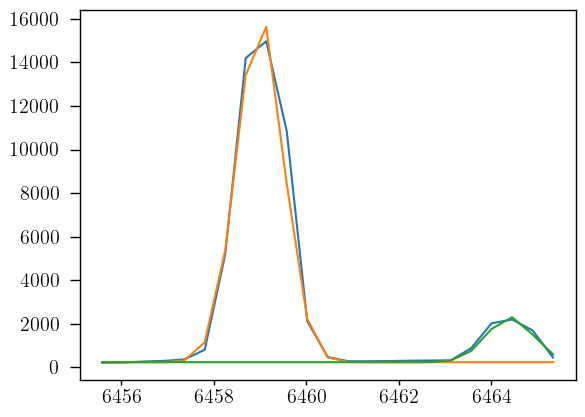

In [74]:
plt.plot(x_arc_5875, y_arc_5875)
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 20000, 6459, 0, 0.5))
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 2600, 6464.4, 0, 0.5))

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 145.96it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [52.11496345 44.05267922 49.77679019]


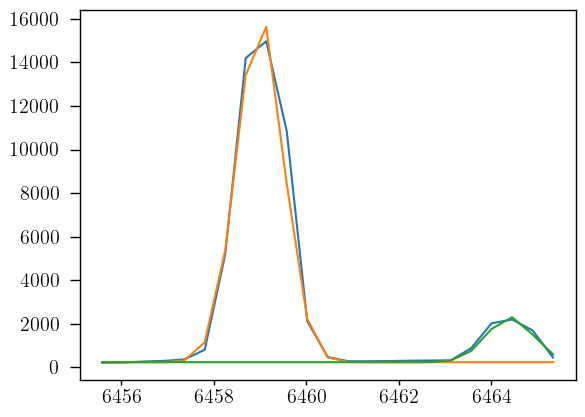

In [75]:
plt.plot(x_arc_5875, y_arc_5875)
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 20000, 6459, 0, 0.5))
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, 2600, 6464.4, 0, 0.5))

params_arc_5875 = Parameters()
params_arc_5875.add('z', value=0.0, vary=False)
params_arc_5875.add('mu1', value=6459, vary=False)
params_arc_5875.add('mu2', value=6464.4, vary=False)
params_arc_5875.add('arc1', value=20000, min=0.)
params_arc_5875.add('arc2', value=2600, min=0.)
params_arc_5875.add('sigma', value=0.5, min=0.)
params_arc_5875.add('bkg', value=240, vary=False)

def residual_arc_5875(params_arc_5875, x, data, uncertainty):
    
    z = params_arc_5875['z']
    mu1 = params_arc_5875['mu1']
    mu2 = params_arc_5875['mu2']
    flux1 = params_arc_5875['arc1']
    flux2 = params_arc_5875['arc2']
    sigma = params_arc_5875['sigma']
    bkg = params_arc_5875['bkg']
    
    x = x_arc_5875
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_5875) / 10


np.random.seed(21)
out_arc_5875 = minimize(residual_arc_5875, params_arc_5875, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [76]:
out_arc_5875.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6459.00000,,,6459,-inf,inf,False
mu2,6464.40000,,,6464.4,-inf,inf,False
arc1,21277.3961,10.7778693,(0.05%),20000,0.00000000,inf,True
arc2,2803.93897,9.34081603,(0.33%),2600,0.00000000,inf,True
sigma,0.52643341,2.9268e-04,(0.06%),0.5,0.00000000,inf,True
bkg,240.000000,,,240,-inf,inf,False


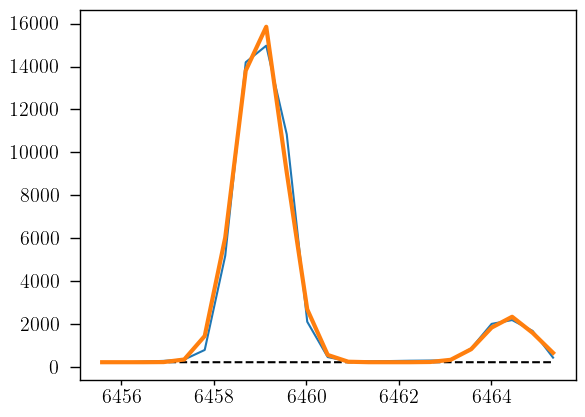

In [77]:
arc1_5875 = out_arc_5875.flatchain.arc1.mean()
arc2_5875 = out_arc_5875.flatchain.arc2.mean()
sigma_arc_5875 = out_arc_5875.flatchain.sigma.mean()

plt.plot(x_arc_5875, y_arc_5875)

plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, arc1_5875, 6459, 0, sigma_arc_5875), ls='--', color='black')
plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, arc2_5875, 6464.4, 0, sigma_arc_5875), ls='--', color='black')

plt.plot(x_arc_5875, 240 + gaussian(x_arc_5875, arc1_5875, 6459, 0, sigma_arc_5875) \
                         + gaussian(x_arc_5875, arc2_5875, 6464.4, 0, sigma_arc_5875), lw=3
)

# HeI 4471

### Arc lines

In [86]:
wave_cat['HeI4471']*(1 + z_BN[igal])

4912.81529574

In [87]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4471 = [wave_cat['HeI4471']*(1 + z_BN[igal]), wave_cat['HeI4471']*(1 + z_BN[igal]) + 10]
mask_arc_4471 = (wcal_blue[10].data['wave_soln'][0] >= wlims_4471[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_4471[1])

# Arc spectra around the fitted line
x_arc_4471 = wcal_blue[10].data['wave_soln'][0][mask_arc_4471]
y_arc_4471 = wcal_blue[27].data[:, 4][mask_arc_4471]

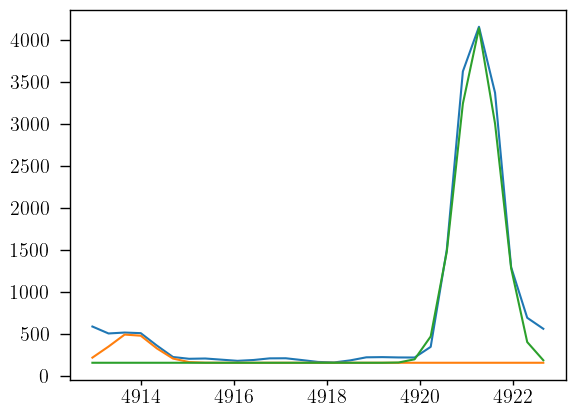

In [88]:
plt.plot(x_arc_4471, y_arc_4471)
plt.plot(x_arc_4471, 160 + gaussian(x_arc_4471, 400, 4913.8, 0, 0.45))
plt.plot(x_arc_4471, 160 + gaussian(x_arc_4471, 4500, 4921.25, 0, 0.45))

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 146.30it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [67.92804023 55.34345578 61.32998859]


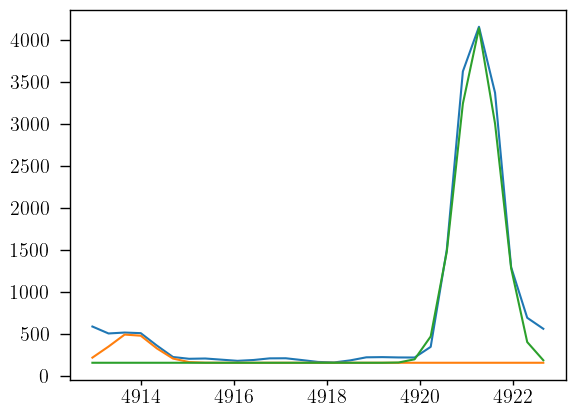

In [89]:
plt.plot(x_arc_4471, y_arc_4471)
plt.plot(x_arc_4471, 160 + gaussian(x_arc_4471, 400, 4913.8, 0, 0.45))
plt.plot(x_arc_4471, 160 + gaussian(x_arc_4471, 4500, 4921.25, 0, 0.45))

params_arc_4471 = Parameters()
params_arc_4471.add('z', value=0.0, vary=False)
params_arc_4471.add('mu1', value=4913.8, vary=False)
params_arc_4471.add('mu2', value=4921.25, vary=False)
params_arc_4471.add('arc1', value=400, min=0.)
params_arc_4471.add('arc2', value=4500, min=0.)
params_arc_4471.add('sigma', value=0.45, min=0.)
params_arc_4471.add('bkg', value=160, vary=False)

def residual_arc_4471(params_arc_4471, x, data, uncertainty):
    
    z = params_arc_4471['z']
    mu1 = params_arc_4471['mu1']
    mu2 = params_arc_4471['mu2']
    flux1 = params_arc_4471['arc1']
    flux2 = params_arc_4471['arc2']
    sigma = params_arc_4471['sigma']
    bkg = params_arc_4471['bkg']
    
    x = x_arc_4471
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model = bkg + model1 + model2
    return (model - y_arc_4471) / 10


np.random.seed(21)
out_arc_4471 = minimize(residual_arc_4471, params_arc_4471, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [90]:
out_arc_4471.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4913.80000,,,4913.8,-inf,inf,False
mu2,4921.25000,,,4921.25,-inf,inf,False
arc1,520.734073,7.66516679,(1.47%),400,0.00000000,inf,True
arc2,4875.04113,9.32564816,(0.19%),4500,0.00000000,inf,True
sigma,0.46537987,0.00101821,(0.22%),0.45,0.00000000,inf,True
bkg,160.000000,,,160,-inf,inf,False


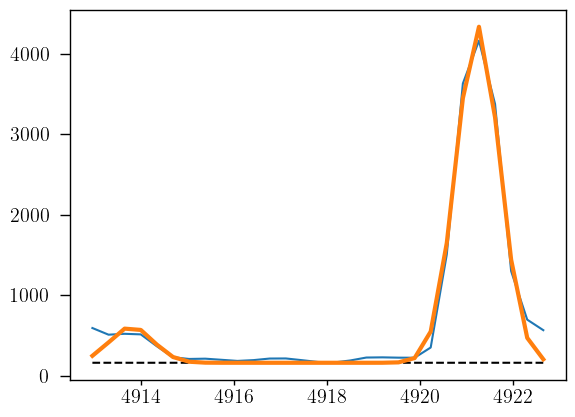

In [91]:
arc1_4471 = out_arc_4471.flatchain.arc1.mean()
arc2_4471 = out_arc_4471.flatchain.arc2.mean()
sigma_arc_4471 = out_arc_4471.flatchain.sigma.mean()

plt.plot(x_arc_4471, y_arc_4471)

plt.plot(x_arc_4471, 160 + gaussian(x_arc_4471, arc1_4471, 4913.8, 0, sigma_arc_4471), ls='--', color='black')
plt.plot(x_arc_4471, 160 + gaussian(x_arc_4471, arc2_4471, 4921.25, 0, sigma_arc_4471), ls='--', color='black')

plt.plot(x_arc_4471, 160 + gaussian(x_arc_4471, arc1_4471, 4913.8, 0, sigma_arc_4471) \
                         + gaussian(x_arc_4471, arc2_4471, 4921.25, 0, sigma_arc_4471), lw=3
)

# [SII]6716 + [SII]6730

### Arc lines

In [100]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6730 = [wave_cat['[SII]6730']*(1 + z_BN[igal]) - 5, wave_cat['[SII]6730']*(1 + z_BN[igal]) + 20]
mask_arc_6730 = (wcal_red[14].data['wave_soln'][0] >= wlims_6730[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_6730[1])

# Arc spectra around the fitted line
x_arc_6730 = wcal_red[14].data['wave_soln'][0][mask_arc_6730]
y_arc_6730 = wcal_red[21].data[:, 6][mask_arc_6730]

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 122.04it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [56.19851786 70.01279174 70.58865673 59.99323256]


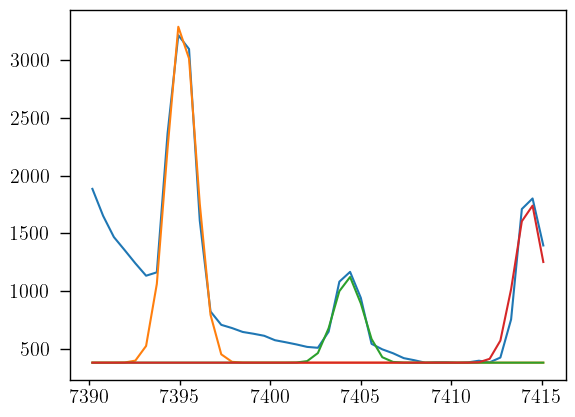

In [101]:
plt.plot(x_arc_6730, y_arc_6730)
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, 6000, 7395.1, 0, 0.8))
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, 1500, 7404.3, 0, 0.8))
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, 2800, 7414.3, 0, 0.8))

params_arc_6730 = Parameters()
params_arc_6730.add('z', value=0.0, vary=False)
params_arc_6730.add('mu1', value=7395.1, vary=False)
params_arc_6730.add('mu2', value=7404.3, vary=False)
params_arc_6730.add('mu3', value=7414.3, vary=False)
params_arc_6730.add('arc1', value=6000, min=0.)
params_arc_6730.add('arc2', value=1500, min=0.)
params_arc_6730.add('arc3', value=2800, min=0.)
params_arc_6730.add('sigma', value=0.8, min=0.)
params_arc_6730.add('bkg', value=380, vary=False)

def residual_arc_6730(params_arc_6730, x, data, uncertainty):
    
    z = params_arc_6730['z']
    mu1 = params_arc_6730['mu1']
    mu2 = params_arc_6730['mu2']
    mu3 = params_arc_6730['mu3']
    flux1 = params_arc_6730['arc1']
    flux2 = params_arc_6730['arc2']
    flux3 = params_arc_6730['arc3']
    sigma = params_arc_6730['sigma']
    bkg = params_arc_6730['bkg']
    
    x = x_arc_6730
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_6730) / 10

np.random.seed(21)
out_arc_6730 = minimize(residual_arc_6730, params_arc_6730, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

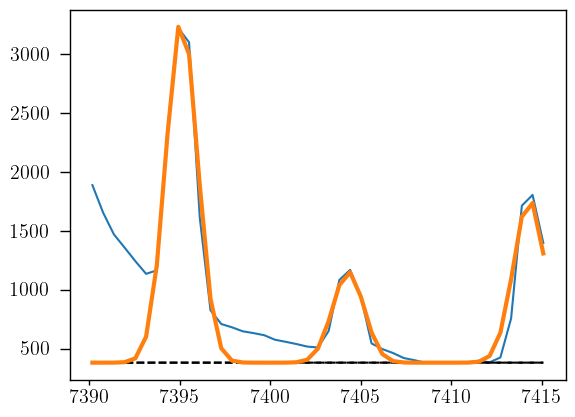

In [102]:
arc1_6730 = out_arc_6730.flatchain.arc1.mean()
arc2_6730 = out_arc_6730.flatchain.arc2.mean()
arc3_6730 = out_arc_6730.flatchain.arc3.mean()
sigma_arc_6730 = out_arc_6730.flatchain.sigma.mean()

plt.plot(x_arc_6730, y_arc_6730)

plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, arc1_6730, 7395.1, 0, sigma_arc_6730), ls='--', color='black')
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, arc2_6730, 7404.3, 0, sigma_arc_6730), ls='--', color='black')
plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, arc3_6730, 7414.3, 0, sigma_arc_6730), ls='--', color='black')

plt.plot(x_arc_6730, 380 + gaussian(x_arc_6730, arc1_6730, 7395.1, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc2_6730, 7404.3, 0, sigma_arc_6730) \
         + gaussian(x_arc_6730, arc3_6730, 7414.3, 0, sigma_arc_6730), lw=3
)

# H$\beta$

### Arc lines

In [112]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hb = [wave_cat['Hb']*(1 + z_BN[igal]) - 20, wave_cat['Hb']*(1 + z_BN[igal]) + 20]
mask_arc_hb = (wcal_red[8].data['wave_soln'][0] >= wlims_hb[0]) & (wcal_red[8].data['wave_soln'][0] < wlims_hb[1])

# Arc spectra around the fitted line
x_arc_hb = wcal_red[8].data['wave_soln'][0][mask_arc_hb]
y_arc_hb = wcal_red[21].data[:, 3][mask_arc_hb]

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 118.13it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [68.78052945 52.03564052 62.43344232 69.60317048]


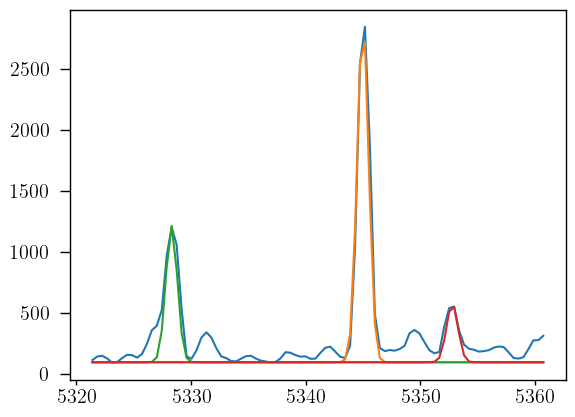

In [113]:
plt.plot(x_arc_hb, y_arc_hb)
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, 3500, 5345, 0, 0.5))
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, 1400, 5328.3, 0, 0.5))
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, 600, 5352.8, 0, 0.5))

params_arc_hb = Parameters()
params_arc_hb.add('z', value=0.0, vary=False)
params_arc_hb.add('mu1', value=5345, vary=False)
params_arc_hb.add('mu2', value=5328.3, vary=False)
params_arc_hb.add('mu3', value=5352.8, vary=False)
params_arc_hb.add('arc1', value=3500, min=0.)
params_arc_hb.add('arc2', value=1400, min=0.)
params_arc_hb.add('arc3', value=600, min=0.)
params_arc_hb.add('sigma', value=0.5, min=0.)
params_arc_hb.add('bkg', value=100, vary=False)

def residual_arc_hb(params_arc_hb, x, data, uncertainty):
    
    z = params_arc_hb['z']
    mu1 = params_arc_hb['mu1']
    mu2 = params_arc_hb['mu2']
    mu3 = params_arc_hb['mu3']
    flux1 = params_arc_hb['arc1']
    flux2 = params_arc_hb['arc2']
    flux3 = params_arc_hb['arc3']
    sigma = params_arc_hb['sigma']
    bkg = params_arc_hb['bkg']
    
    x = x_arc_hb
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_hb) / 10

np.random.seed(21)
out_arc_hb = minimize(residual_arc_hb, params_arc_hb, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

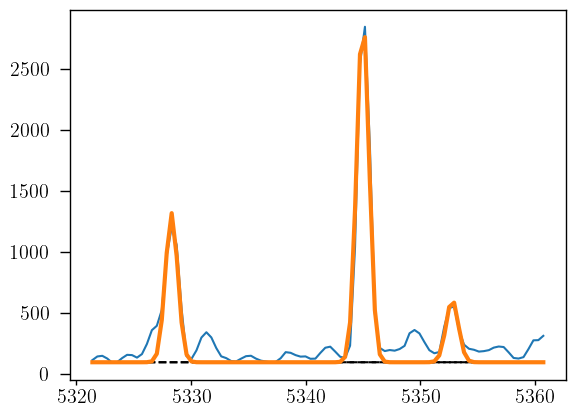

In [114]:
arc1_hb = out_arc_hb.flatchain.arc1.mean()
arc2_hb = out_arc_hb.flatchain.arc2.mean()
arc3_hb = out_arc_hb.flatchain.arc3.mean()
sigma_arc_hb = out_arc_hb.flatchain.sigma.mean()

plt.plot(x_arc_hb, y_arc_hb)

plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, arc1_hb, 5345, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, arc2_hb, 5328.3, 0, sigma_arc_hb), ls='--', color='black')
plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, arc3_hb, 5352.8, 0, sigma_arc_hb), ls='--', color='black')

plt.plot(x_arc_hb, 100 + gaussian(x_arc_hb, arc1_hb, 5345, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc2_hb, 5328.3, 0, sigma_arc_hb) \
         + gaussian(x_arc_hb, arc3_hb, 5352.8, 0, sigma_arc_hb), lw=3
)

# H$\gamma$

### Arc lines

In [124]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hg = [wave_cat['Hg']*(1 + z_BN[igal]) - 10, wave_cat['Hg']*(1 + z_BN[igal])]
mask_arc_hg = (wcal_blue[10].data['wave_soln'][0] >= wlims_hg[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_hg[1])

# Arc spectra around the fitted line
x_arc_hg = wcal_blue[10].data['wave_soln'][0][mask_arc_hg]
y_arc_hg = wcal_blue[27].data[:, 4][mask_arc_hg]

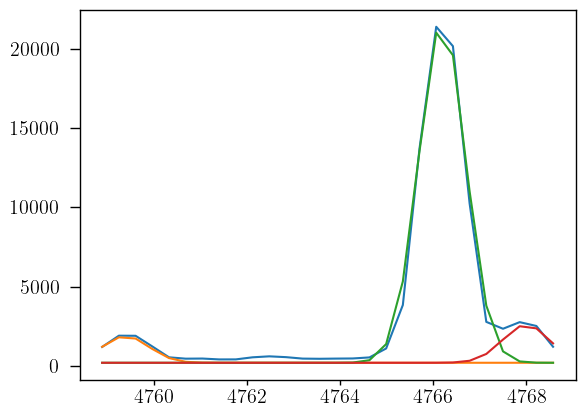

In [125]:
plt.plot(x_arc_hg, y_arc_hg)
plt.plot(x_arc_hg, 200 + gaussian(x_arc_hg,  2100, 4759.4, 0, 0.5))
plt.plot(x_arc_hg, 200 + gaussian(x_arc_hg, 27000, 4766.2, 0, 0.5))
plt.plot(x_arc_hg, 200 + gaussian(x_arc_hg,  3000,   4768, 0, 0.5))

In [126]:
params_arc_hg = Parameters()
params_arc_hg.add('z', value=0.0, vary=False)
params_arc_hg.add('mu1', value=4759.4, vary=False)
params_arc_hg.add('mu2', value=4766.2, vary=False)
params_arc_hg.add('mu3', value=  4768, vary=False)
params_arc_hg.add('arc1', value= 2100, min=0.)
params_arc_hg.add('arc2', value=27000, min=0.)
params_arc_hg.add('arc3', value= 3000, min=0.)
params_arc_hg.add('sigma', value=0.5, min=0.)
params_arc_hg.add('bkg', value=200, vary=False)

def residual_arc_hg(params_arc_hg, x, data, uncertainty):
    
    z = params_arc_hg['z']
    mu1 = params_arc_hg['mu1']
    mu2 = params_arc_hg['mu2']
    mu3 = params_arc_hg['mu3']
    flux1 = params_arc_hg['arc1']
    flux2 = params_arc_hg['arc2']
    flux3 = params_arc_hg['arc3']
    sigma = params_arc_hg['sigma']
    bkg = params_arc_hg['bkg']
    
    x = x_arc_hg
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_hg) / 10

np.random.seed(21)
out_arc_hg = minimize(residual_arc_hg, params_arc_hg, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 122.73it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [61.4316202  61.99416992 34.93355727 54.13155388]


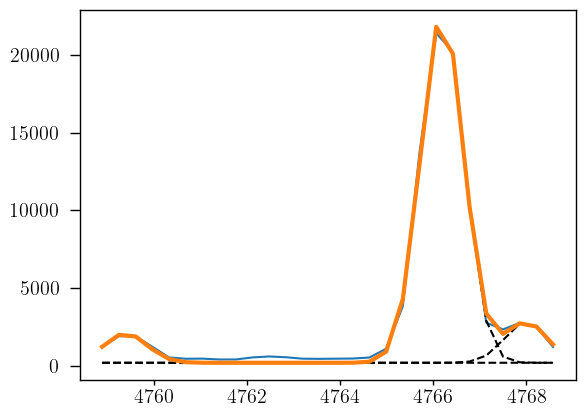

In [127]:
arc1_hg = out_arc_hg.flatchain.arc1.mean()
arc2_hg = out_arc_hg.flatchain.arc2.mean()
arc3_hg = out_arc_hg.flatchain.arc3.mean()
sigma_arc_hg = out_arc_hg.flatchain.sigma.mean()

plt.plot(x_arc_hg, y_arc_hg)

plt.plot(x_arc_hg, 200 + gaussian(x_arc_hg, arc1_hg, 4759.4, 0, sigma_arc_hg), ls='--', color='black')
plt.plot(x_arc_hg, 200 + gaussian(x_arc_hg, arc2_hg, 4766.2, 0, sigma_arc_hg), ls='--', color='black')
plt.plot(x_arc_hg, 200 + gaussian(x_arc_hg, arc3_hg,   4768, 0, sigma_arc_hg), ls='--', color='black')

plt.plot(x_arc_hg, 200 + gaussian(x_arc_hg, arc1_hg, 4759.4, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc2_hg, 4766.2, 0, sigma_arc_hg) \
                       + gaussian(x_arc_hg, arc3_hg,   4768, 0, sigma_arc_hg), lw=3
)

# H$\delta$

### Arc lines

In [137]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_hd = [wave_cat['Hd']*(1 + z_BN[igal]) + 2, wave_cat['Hd']*(1 + z_BN[igal]) + 10]
mask_arc_hd = (wcal_blue[10].data['wave_soln'][0] >= wlims_hd[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_hd[1])

# Arc spectra around the fitted line
x_arc_hd = wcal_blue[10].data['wave_soln'][0][mask_arc_hd]
y_arc_hd = wcal_blue[27].data[:, 4][mask_arc_hd]

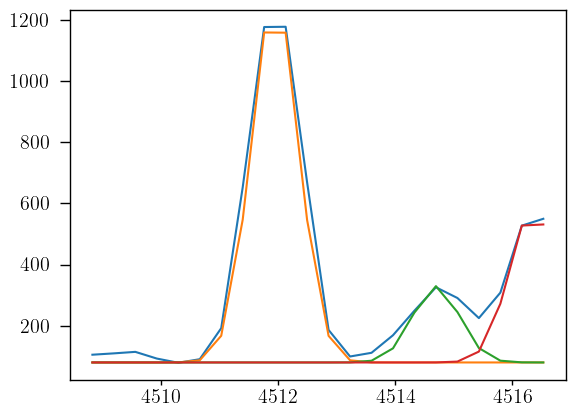

In [138]:
plt.plot(x_arc_hd, y_arc_hd)
plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd,  1200, 4511.95, 0, 0.4))
plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd,   250,  4514.7, 0, 0.4))
plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd,   500, 4516.35, 0, 0.4))

In [139]:
params_arc_hd = Parameters()
params_arc_hd.add('z', value=0.0, vary=False)
params_arc_hd.add('mu1', value=4511.95, vary=False)
params_arc_hd.add('mu2', value= 4514.7, vary=False)
params_arc_hd.add('mu3', value=4516.35, vary=False)
params_arc_hd.add('arc1', value=1200, min=0.)
params_arc_hd.add('arc2', value= 250, min=0.)
params_arc_hd.add('arc3', value= 500, min=0.)
params_arc_hd.add('sigma', value=0.4, min=0.)
params_arc_hd.add('bkg', value=80, vary=False)

def residual_arc_hd(params_arc_hd, x, data, uncertainty):
    
    z = params_arc_hd['z']
    mu1 = params_arc_hd['mu1']
    mu2 = params_arc_hd['mu2']
    mu3 = params_arc_hd['mu3']
    flux1 = params_arc_hd['arc1']
    flux2 = params_arc_hd['arc2']
    flux3 = params_arc_hd['arc3']
    sigma = params_arc_hd['sigma']
    bkg = params_arc_hd['bkg']
    
    x = x_arc_hd
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_hd) / 10

np.random.seed(21)
out_arc_hd = minimize(residual_arc_hd, params_arc_hd, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 124.49it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [52.5886789  39.97555445 50.77659927 56.43680363]


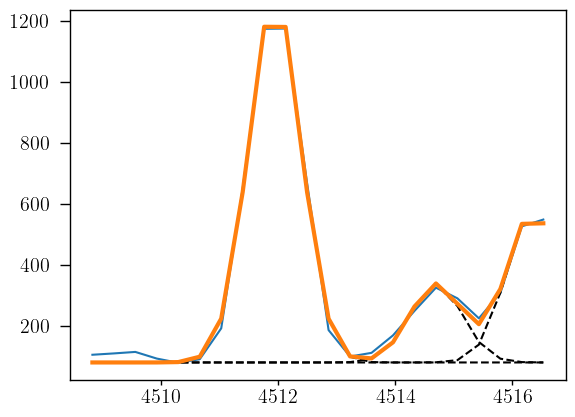

In [140]:
arc1_hd = out_arc_hd.flatchain.arc1.mean()
arc2_hd = out_arc_hd.flatchain.arc2.mean()
arc3_hd = out_arc_hd.flatchain.arc3.mean()
sigma_arc_hd = out_arc_hd.flatchain.sigma.mean()

plt.plot(x_arc_hd, y_arc_hd)

plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd, arc1_hd, 4511.95, 0, sigma_arc_hd), ls='--', color='black')
plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd, arc2_hd,  4514.7, 0, sigma_arc_hd), ls='--', color='black')
plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd, arc3_hd, 4516.35, 0, sigma_arc_hd), ls='--', color='black')

plt.plot(x_arc_hd, 80 + gaussian(x_arc_hd, arc1_hd, 4511.95, 0, sigma_arc_hd) \
                      + gaussian(x_arc_hd, arc2_hd,  4514.7, 0, sigma_arc_hd) \
                      + gaussian(x_arc_hd, arc3_hd, 4516.35, 0, sigma_arc_hd), lw=3
)

# HeII 4686

### Arc lines

In [149]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4685 = [wave_cat['HeII4685']*(1 + z_BN[igal]), wave_cat['HeII4685']*(1 + z_BN[igal]) + 10]
mask_arc_4685 = (wcal_red[6].data['wave_soln'][0] >= wlims_4685[0]) & (wcal_red[6].data['wave_soln'][0] < wlims_4685[1])

# Arc spectra around the fitted line
x_arc_4685 = wcal_red[6].data['wave_soln'][0][mask_arc_4685]
y_arc_4685 = wcal_red[21].data[:, 2][mask_arc_4685]

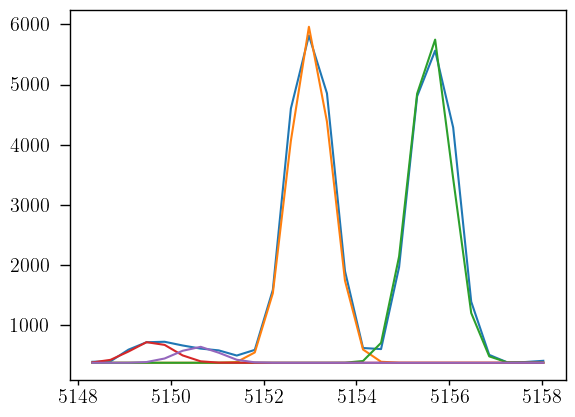

In [150]:
plt.plot(x_arc_4685, y_arc_4685)
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, 6300, 5153, 0, 0.45))
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, 6200, 5155.6, 0, 0.45))
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, 400, 5149.6, 0, 0.45))
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, 300, 5150.6, 0, 0.45))

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 108.35it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [68.84193294 92.25386415 70.28272662 80.98746228 82.08835639]


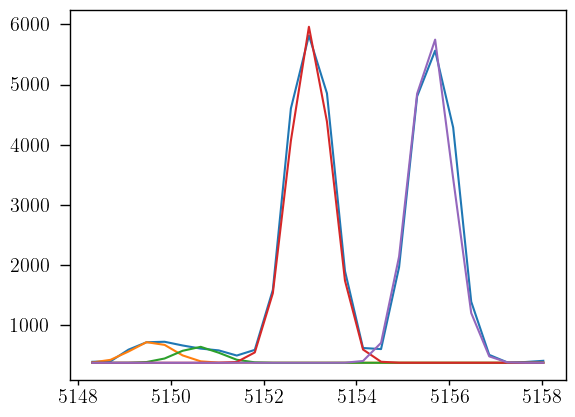

In [151]:
plt.plot(x_arc_4685, y_arc_4685)
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, 400, 5149.6, 0, 0.45))
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, 300, 5150.6, 0, 0.45))
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, 6300, 5153, 0, 0.45))
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, 6200, 5155.6, 0, 0.45))

params_arc_4685 = Parameters()
params_arc_4685.add('z', value=0.0, vary=False)
params_arc_4685.add('mu1', value=5149.6, vary=False)
params_arc_4685.add('mu2', value=5150.6, vary=False)
params_arc_4685.add('mu3', value=5153, vary=False)
params_arc_4685.add('mu4', value=5155.6, vary=False)
params_arc_4685.add('arc1', value=400, min=0.)
params_arc_4685.add('arc2', value=300, min=0.)
params_arc_4685.add('arc3', value=6300, min=0.)
params_arc_4685.add('arc4', value=6200, min=0.)
params_arc_4685.add('sigma', value=0.45, min=0.)
params_arc_4685.add('bkg', value=380, vary=False)

def residual_arc_4685(params_arc_4685, x, data, uncertainty):
    
    z = params_arc_4685['z']
    mu1 = params_arc_4685['mu1']
    mu2 = params_arc_4685['mu2']
    mu3 = params_arc_4685['mu3']
    mu4 = params_arc_4685['mu4']
    flux1 = params_arc_4685['arc1']
    flux2 = params_arc_4685['arc2']
    flux3 = params_arc_4685['arc3']
    flux4 = params_arc_4685['arc4']
    sigma = params_arc_4685['sigma']
    bkg = params_arc_4685['bkg']
    
    x = x_arc_4685
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_4685) / 10

np.random.seed(21)
out_arc_4685 = minimize(residual_arc_4685, params_arc_4685, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [152]:
out_arc_4685.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,5149.60000,,,5149.6,-inf,inf,False
mu2,5150.60000,,,5150.6,-inf,inf,False
mu3,5153.00000,,,5153,-inf,inf,False
mu4,5155.60000,,,5155.6,-inf,inf,False
arc1,397.233111,8.51244745,(2.14%),400,0.00000000,inf,True
arc2,275.058381,8.58663214,(3.12%),300,0.00000000,inf,True
arc3,6809.96976,9.05309589,(0.13%),6300,0.00000000,inf,True
arc4,6496.75360,8.99072415,(0.14%),6200,0.00000000,inf,True
sigma,0.47460011,5.2961e-04,(0.11%),0.45,0.00000000,inf,True


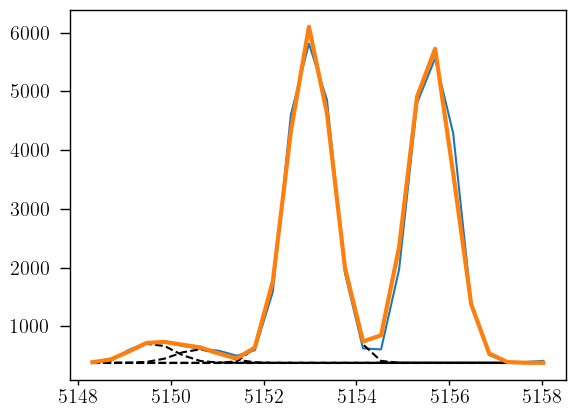

In [153]:
arc1_4685 = out_arc_4685.flatchain.arc1.mean()
arc2_4685 = out_arc_4685.flatchain.arc2.mean()
arc3_4685 = out_arc_4685.flatchain.arc3.mean()
arc4_4685 = out_arc_4685.flatchain.arc4.mean()
sigma_arc_4685 = out_arc_4685.flatchain.sigma.mean()

plt.plot(x_arc_4685, y_arc_4685)

plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, arc1_4685, 5149.6, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, arc2_4685, 5150.6, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, arc3_4685,  5153, 0, sigma_arc_4685), ls='--', color='black')
plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, arc4_4685, 4095.9, 0, sigma_arc_4685), ls='--', color='black')

plt.plot(x_arc_4685, 380 + gaussian(x_arc_4685, arc1_4685, 5149.6, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc2_4685, 5150.6, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc3_4685,   5153, 0, sigma_arc_4685) \
         + gaussian(x_arc_4685, arc4_4685, 5155.6, 0, sigma_arc_4685), lw=3
)

# [OII]3726 + [OII]3729

### Arc lines

In [164]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_3729 = [wave_cat['[OII]3729']*(1 + z_BN[igal]) - 10, wave_cat['[OII]3729']*(1 + z_BN[igal]) + 10]
mask_arc_3729 = (wcal_blue[6].data['wave_soln'][0] >= wlims_3729[0]) & (wcal_blue[6].data['wave_soln'][0] < wlims_3729[1])

# Arc spectra around the fitted line
x_arc_3729 = wcal_blue[6].data['wave_soln'][0][mask_arc_3729]
y_arc_3729 = wcal_blue[27].data[:, 2][mask_arc_3729]

100%|███████████████████████████████████████| 2500/2500 [00:33<00:00, 75.46it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 56.96894038  88.81713093 145.99239809  63.64365113 121.81365773
  59.14712544  60.66126412  76.95906489]


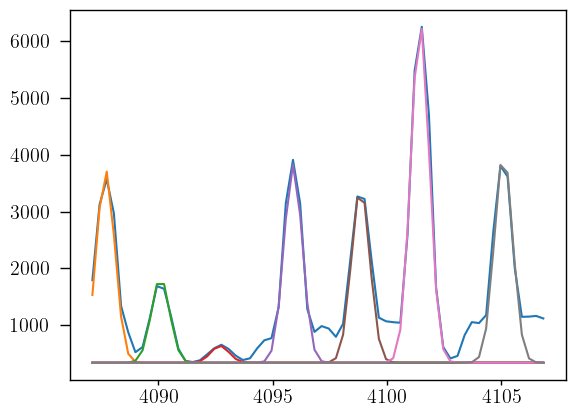

In [165]:
plt.plot(x_arc_3729, y_arc_3729)
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 3400, 4087.7, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 1500, 4090.1, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 300, 4092.7, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 3500, 4095.9, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 3100, 4098.85, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 6000, 4101.45, 0, 0.4))
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, 3700, 4105.1, 0, 0.4))

params_arc_3729 = Parameters()
params_arc_3729.add('z', value=0.0, vary=False)
params_arc_3729.add('mu1', value=4087.7, vary=False)
params_arc_3729.add('mu2', value=4090.1, vary=False)
params_arc_3729.add('mu3', value=4092.7, vary=False)
params_arc_3729.add('mu4', value=4095.9, vary=False)
params_arc_3729.add('mu5', value=4098.85, vary=False)
params_arc_3729.add('mu6', value=4101.45, vary=False)
params_arc_3729.add('mu7', value=4105.1, vary=False)
params_arc_3729.add('arc1', value=3400, min=0.)
params_arc_3729.add('arc2', value=1500, min=0.)
params_arc_3729.add('arc3', value=300, min=0.)
params_arc_3729.add('arc4', value=3500, min=0.)
params_arc_3729.add('arc5', value=3100, min=0.)
params_arc_3729.add('arc6', value=6000, min=0.)
params_arc_3729.add('arc7', value=3700, min=0.)
params_arc_3729.add('sigma', value=0.4, min=0.)
params_arc_3729.add('bkg', value=340, vary=False)

def residual_arc_3729(params_arc_3729, x, data, uncertainty):
    
    z = params_arc_3729['z']
    mu1 = params_arc_3729['mu1']
    mu2 = params_arc_3729['mu2']
    mu3 = params_arc_3729['mu3']
    mu4 = params_arc_3729['mu4']
    mu5 = params_arc_3729['mu5']
    mu6 = params_arc_3729['mu6']
    mu7 = params_arc_3729['mu7']
    flux1 = params_arc_3729['arc1']
    flux2 = params_arc_3729['arc2']
    flux3 = params_arc_3729['arc3']
    flux4 = params_arc_3729['arc4']
    flux5 = params_arc_3729['arc5']
    flux6 = params_arc_3729['arc6']
    flux7 = params_arc_3729['arc7']
    sigma = params_arc_3729['sigma']
    bkg = params_arc_3729['bkg']
    
    x = x_arc_3729
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model6 = gaussian(x, flux6, mu6, z, sigma)
    model7 = gaussian(x, flux7, mu7, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5 + model6 + model7
    return (model - y_arc_3729) / 10

np.random.seed(21)
out_arc_3729 = minimize(residual_arc_3729, params_arc_3729, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

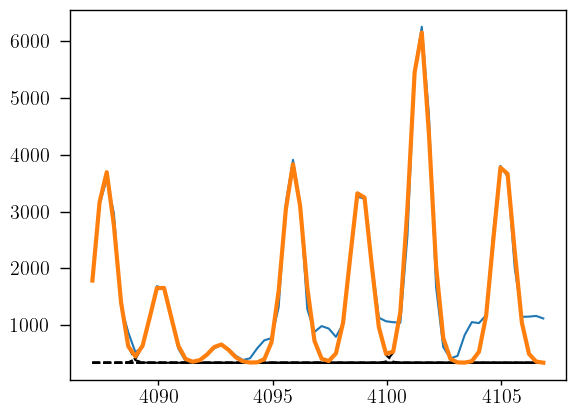

In [166]:
arc1_3729 = out_arc_3729.flatchain.arc1.mean()
arc2_3729 = out_arc_3729.flatchain.arc2.mean()
arc3_3729 = out_arc_3729.flatchain.arc3.mean()
arc4_3729 = out_arc_3729.flatchain.arc4.mean()
arc5_3729 = out_arc_3729.flatchain.arc5.mean()
arc6_3729 = out_arc_3729.flatchain.arc6.mean()
arc7_3729 = out_arc_3729.flatchain.arc7.mean()
sigma_arc_3729 = out_arc_3729.flatchain.sigma.mean()

plt.plot(x_arc_3729, y_arc_3729)

plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc1_3729, 4087.7, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc2_3729, 4090.1, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc3_3729, 4092.7, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc4_3729, 4095.9, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc5_3729, 4098.85, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc6_3729, 4101.45, 0, sigma_arc_3729), ls='--', color='black')
plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc7_3729, 4105.1, 0, sigma_arc_3729), ls='--', color='black')

plt.plot(x_arc_3729, 340 + gaussian(x_arc_3729, arc1_3729, 4087.7, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc2_3729, 4090.1, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc3_3729, 4092.7, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc4_3729, 4095.9, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc5_3729, 4098.85, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc6_3729, 4101.45, 0, sigma_arc_3729) \
         + gaussian(x_arc_3729, arc7_3729, 4105.1, 0, sigma_arc_3729), lw=3
)

# [NII]5755

### Arc lines

In [176]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5755 = [wave_cat['[NII]5755']*(1 + z_BN[igal]) - 5, wave_cat['[NII]5755']*(1 + z_BN[igal]) + 20]
mask_arc_5755 = (wcal_red[10].data['wave_soln'][0] >= wlims_5755[0]) & (wcal_red[10].data['wave_soln'][0] < wlims_5755[1])

# Arc spectra around the fitted line
x_arc_5755 = wcal_red[10].data['wave_soln'][0][mask_arc_5755]
y_arc_5755 = wcal_red[21].data[:, 4][mask_arc_5755]

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 107.88it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [87.52536076 57.71430344 40.25134037 45.26160528 65.28724211]


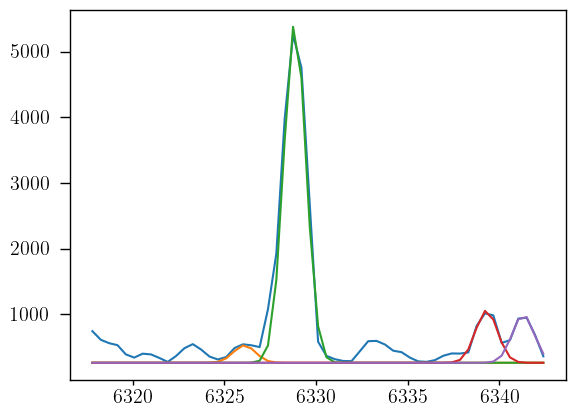

In [177]:
plt.plot(x_arc_5755, y_arc_5755)
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, 400, 6326.1, 0, 0.6))
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, 7800, 6328.85, 0, 0.6))
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, 1200, 6339.3, 0, 0.6))
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, 1100, 6341.3, 0, 0.6))

params_arc_5755 = Parameters()
params_arc_5755.add('z', value=0.0, vary=False)
params_arc_5755.add('mu1', value=6326.1, vary=False)
params_arc_5755.add('mu2', value=6328.85, vary=False)
params_arc_5755.add('mu3', value=6339.3, vary=False)
params_arc_5755.add('mu4', value=6341.3, vary=False)
params_arc_5755.add('arc1', value=400, min=0.)
params_arc_5755.add('arc2', value=7800, min=0.)
params_arc_5755.add('arc3', value=1200, min=0.)
params_arc_5755.add('arc4', value=1100, min=0.)
params_arc_5755.add('sigma', value=0.6, min=0.)
params_arc_5755.add('bkg', value=260, vary=False)

def residual_arc_5755(params_arc_5755, x, data, uncertainty):
    
    z = params_arc_5755['z']
    mu1 = params_arc_5755['mu1']
    mu2 = params_arc_5755['mu2']
    mu3 = params_arc_5755['mu3']
    mu4 = params_arc_5755['mu4']
    flux1 = params_arc_5755['arc1']
    flux2 = params_arc_5755['arc2']
    flux3 = params_arc_5755['arc3']
    flux4 = params_arc_5755['arc4']
    sigma = params_arc_5755['sigma']
    bkg = params_arc_5755['bkg']
    
    x = x_arc_5755
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_5755) / 10

np.random.seed(21)
out_arc_5755 = minimize(residual_arc_5755, params_arc_5755, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [178]:
out_arc_5755.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,6326.10000,,,6326.1,-inf,inf,False
mu2,6328.85000,,,6328.85,-inf,inf,False
mu3,6339.30000,,,6339.3,-inf,inf,False
mu4,6341.30000,,,6341.3,-inf,inf,False
arc1,533.884335,10.5510871,(1.98%),400,0.00000000,inf,True
arc2,8457.88168,12.4196985,(0.15%),7800,0.00000000,inf,True
arc3,1204.06970,10.3985637,(0.86%),1200,0.00000000,inf,True
arc4,1073.42681,10.3894249,(0.97%),1100,0.00000000,inf,True
sigma,0.65238597,0.00107532,(0.16%),0.6,0.00000000,inf,True


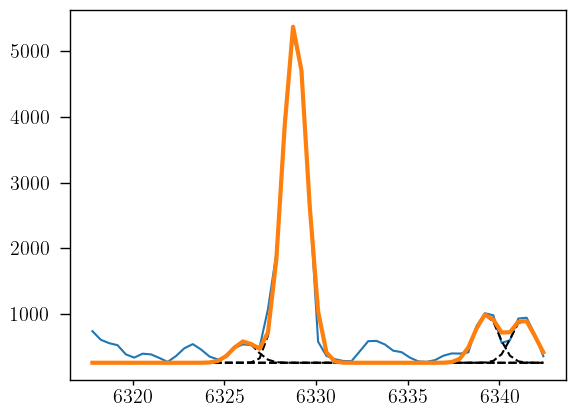

In [179]:
arc1_5755 = out_arc_5755.flatchain.arc1.mean()
arc2_5755 = out_arc_5755.flatchain.arc2.mean()
arc3_5755 = out_arc_5755.flatchain.arc3.mean()
arc4_5755 = out_arc_5755.flatchain.arc4.mean()
sigma_arc_5755 = out_arc_5755.flatchain.sigma.mean()

plt.plot(x_arc_5755, y_arc_5755)

plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc1_5755, 6326.1, 0, sigma_arc_5755), ls='--', color='black')
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc2_5755, 6328.85, 0, sigma_arc_5755), ls='--', color='black')
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc3_5755, 6339.3, 0, sigma_arc_5755), ls='--', color='black')
plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc4_5755, 6341.3, 0, sigma_arc_5755), ls='--', color='black')

plt.plot(x_arc_5755, 260 + gaussian(x_arc_5755, arc1_5755, 6326.1, 0, sigma_arc_5755) \
         + gaussian(x_arc_5755, arc2_5755, 6328.85, 0, sigma_arc_5755) \
         + gaussian(x_arc_5755, arc3_5755, 6339.3, 0, sigma_arc_5755) \
         + gaussian(x_arc_5755, arc4_5755, 6341.3, 0, sigma_arc_5755), lw=3
)

# [SIII]9532

### Arc lines

In [188]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9532 = [wave_cat['[SIII]9532']*(1 + z_BN[igal]) - 10, wave_cat['[SIII]9532']*(1 + z_BN[igal]) + 10]
mask_arc_9532 = (wcal_red[18].data['wave_soln'][0] >= wlims_9532[0]) & (wcal_red[18].data['wave_soln'][0] < wlims_9532[1])

# Arc spectra around the fitted line
x_arc_9532 = wcal_red[18].data['wave_soln'][0][mask_arc_9532]
y_arc_9532 = wcal_red[21].data[:, 8][mask_arc_9532]

100%|██████████████████████████████████████| 2500/2500 [00:13<00:00, 179.59it/s]


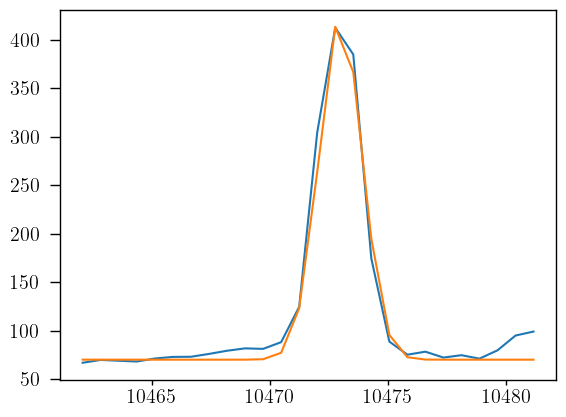

In [189]:
plt.plot(x_arc_9532, y_arc_9532)
plt.plot(x_arc_9532, 70 + gaussian(x_arc_9532, 800, 10473, 0, 0.9))

params_arc_9532 = Parameters()
params_arc_9532.add('z', value=0.0, vary=False)
params_arc_9532.add('mu', value=10473, vary=False)
params_arc_9532.add('arc', value=800, min=0.)
params_arc_9532.add('sigma', value=0.9, min=0.)
params_arc_9532.add('bkg', value=70, vary=False)

def residual_arc_9532(params_arc_9532, x, data, uncertainty):
    
    z = params_arc_9532['z']
    mu = params_arc_9532['mu']
    flux = params_arc_9532['arc']
    sigma = params_arc_9532['sigma']
    bkg = params_arc_9532['bkg']
    
    x = x_arc_9532
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_9532) / 10

np.random.seed(21)
out_arc_9532 = minimize(residual_arc_9532, params_arc_9532, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

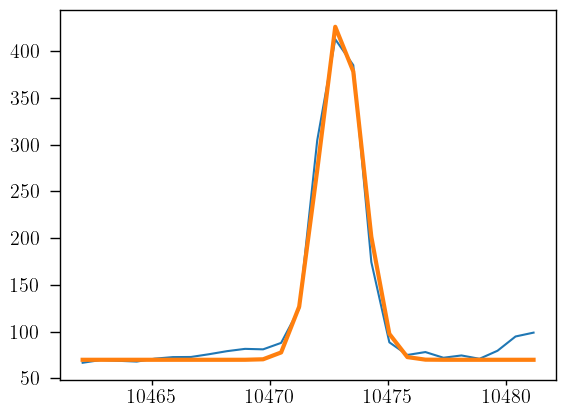

In [190]:
arc_9532 = out_arc_9532.flatchain.arc.mean()
sigma_arc_9532 = out_arc_9532.flatchain.sigma.mean()

plt.plot(x_arc_9532, y_arc_9532)

plt.plot(x_arc_9532, 70 + gaussian(x_arc_9532, arc_9532, 10473, 0, sigma_arc_9532), lw=3
)

# [SIII]9069

### Arc lines

In [199]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_9069 = [wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 70, wave_cat['[SIII]9069']*(1 + z_BN[igal]) + 100]
mask_arc_9069 = (wcal_red[18].data['wave_soln'][0] >= wlims_9069[0]) & (wcal_red[18].data['wave_soln'][0] < wlims_9069[1])

# Arc spectra around the fitted line
x_arc_9069 = wcal_red[18].data['wave_soln'][0][mask_arc_9069]
y_arc_9069 = wcal_red[21].data[:, 8][mask_arc_9069]

100%|██████████████████████████████████████| 2500/2500 [00:13<00:00, 183.15it/s]


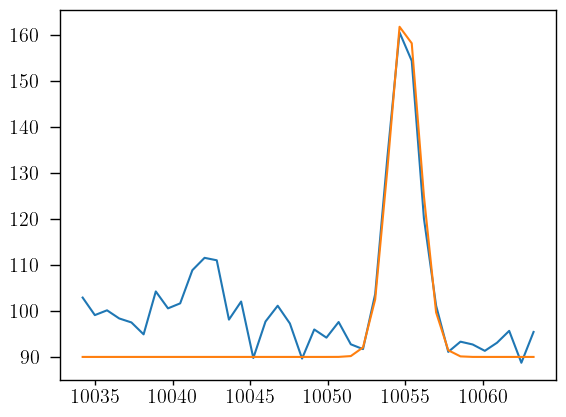

In [200]:
plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, 90 + gaussian(x_arc_9069, 190, 10054.95, 0, 1.0))

params_arc_9069 = Parameters()
params_arc_9069.add('z', value=0.0, vary=False)
params_arc_9069.add('mu', value=10054.95, vary=False)
params_arc_9069.add('arc', value=190, min=0.)
params_arc_9069.add('sigma', value=1.0, min=0.)
params_arc_9069.add('bkg', value=90, vary=False)

def residual_arc_9069(params_arc_9069, x, data, uncertainty):
    
    z = params_arc_9069['z']
    mu = params_arc_9069['mu']
    flux = params_arc_9069['arc']
    sigma = params_arc_9069['sigma']
    bkg = params_arc_9069['bkg']
    
    x = x_arc_9069
    model = bkg + gaussian(x, flux, mu, z, sigma)
    return (model - y_arc_9069) / 10

np.random.seed(21)
out_arc_9069 = minimize(residual_arc_9069, params_arc_9069, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

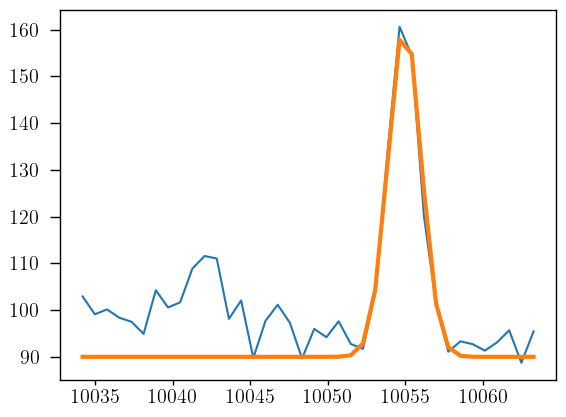

In [201]:
arc_9069 = out_arc_9069.flatchain.arc.mean()
sigma_arc_9069 = out_arc_9069.flatchain.sigma.mean()

plt.plot(x_arc_9069, y_arc_9069)
plt.plot(x_arc_9069, 90 + gaussian(x_arc_9069, arc_9069, 10054.95, 0, sigma_arc_9069), lw=3)

# [OI]6300 + [SIII]6312

### Arc lines

In [210]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_6312 = [wave_cat['[SIII]6312']*(1 + z_BN[igal]), wave_cat['[SIII]6312']*(1 + z_BN[igal]) + 25]
mask_arc_6312 = (wcal_red[12].data['wave_soln'][0] >= wlims_6312[0]) & (wcal_red[12].data['wave_soln'][0] < wlims_6312[1])

# Arc spectra around the fitted line
x_arc_6312 = wcal_red[12].data['wave_soln'][0][mask_arc_6312]
y_arc_6312 = wcal_red[21].data[:, 5][mask_arc_6312]

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 120.67it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [58.69398607 70.71223921 43.33333218 70.55339608]


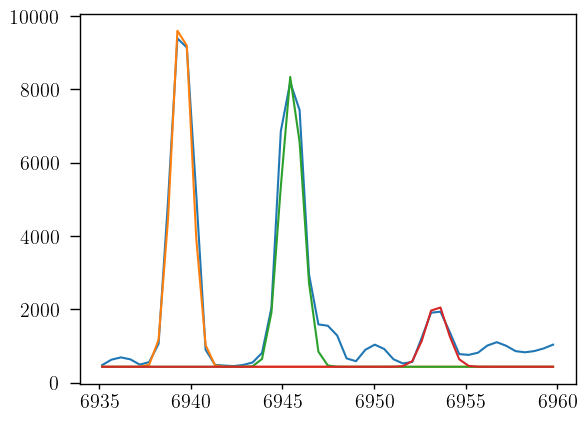

In [211]:
plt.plot(x_arc_6312, y_arc_6312)
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, 13800, 6939.5, 0, 0.55))
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, 12000, 6945.5, 0, 0.6))
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, 2600, 6953.4, 0, 0.6))

params_arc_6312 = Parameters()
params_arc_6312.add('z', value=0.0, vary=False)
params_arc_6312.add('mu1', value=6939.5, vary=False)
params_arc_6312.add('mu2', value=6945.5, vary=False)
params_arc_6312.add('mu3', value=6953.4, vary=False)
params_arc_6312.add('arc1', value=13800, min=0.)
params_arc_6312.add('arc2', value=12000, min=0.)
params_arc_6312.add('arc3', value=2600, min=0.)
params_arc_6312.add('sigma', value=0.57, min=0.)
params_arc_6312.add('bkg', value=430, vary=False)

def residual_arc_6312(params_arc_6312, x, data, uncertainty):
    
    z = params_arc_6312['z']
    mu1 = params_arc_6312['mu1']
    mu2 = params_arc_6312['mu2']
    mu3 = params_arc_6312['mu3']
    flux1 = params_arc_6312['arc1']
    flux2 = params_arc_6312['arc2']
    flux3 = params_arc_6312['arc3']
    sigma = params_arc_6312['sigma']
    bkg = params_arc_6312['bkg']
    
    x = x_arc_6312
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3 
    return (model - y_arc_6312) / 10

np.random.seed(21)
out_arc_6312 = minimize(residual_arc_6312, params_arc_6312, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

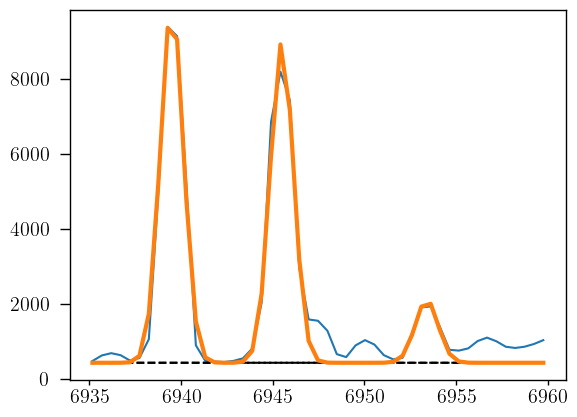

In [212]:
arc1_6312 = out_arc_6312.flatchain.arc1.mean()
arc2_6312 = out_arc_6312.flatchain.arc2.mean()
arc3_6312 = out_arc_6312.flatchain.arc3.mean()
sigma_arc_6312 = out_arc_6312.flatchain.sigma.mean()

plt.plot(x_arc_6312, y_arc_6312)

plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, arc1_6312, 6939.5, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, arc2_6312, 6945.5, 0, sigma_arc_6312), ls='--', color='black')
plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, arc3_6312, 6953.4, 0, sigma_arc_6312), ls='--', color='black')

plt.plot(x_arc_6312, 430 + gaussian(x_arc_6312, arc1_6312, 6939.5, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc2_6312, 6945.5, 0, sigma_arc_6312) \
         + gaussian(x_arc_6312, arc3_6312, 6953.4, 0, sigma_arc_6312), lw=3
)

# [ArIII]7135

### Arc lines

In [221]:
wave_cat['[ArIII]7135']*(1 + z_BN[igal])

7840.10346

In [222]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_7135 = [wave_cat['[ArIII]7135']*(1 + z_BN[igal]) - 10, wave_cat['[ArIII]7135']*(1 + z_BN[igal]) + 20]
mask_arc_7135 = (wcal_red[14].data['wave_soln'][0] >= wlims_7135[0]) & (wcal_red[14].data['wave_soln'][0] < wlims_7135[1])

# Arc spectra around the fitted line
x_arc_7135 = wcal_red[14].data['wave_soln'][0][mask_arc_7135]
y_arc_7135 = wcal_red[21].data[:, 6][mask_arc_7135]

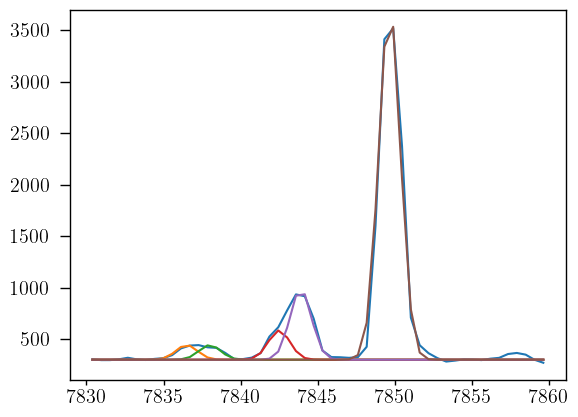

In [223]:
plt.plot(x_arc_7135, y_arc_7135)
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135,  250,  7836.5, 0, 0.7))
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135,  250,    7838, 0, 0.7))
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135,  500,  7842.5, 0, 0.7))
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135, 1200,  7843.9, 0, 0.7))
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135, 6000, 7849.67, 0, 0.7))

In [224]:
params_arc_7135 = Parameters()
params_arc_7135.add('z', value=0.0, vary=False)
params_arc_7135.add('mu1', value= 7836.5, vary=False)
params_arc_7135.add('mu2', value=   7838, vary=False)
params_arc_7135.add('mu3', value= 7842.5, vary=False)
params_arc_7135.add('mu4', value= 7843.9, vary=False)
params_arc_7135.add('mu5', value=7849.67, vary=False)
params_arc_7135.add('arc1', value= 250, min=0.)
params_arc_7135.add('arc2', value= 250, min=0.)
params_arc_7135.add('arc3', value= 500, min=0.)
params_arc_7135.add('arc4', value=1200, min=0.)
params_arc_7135.add('arc5', value=6000, min=0.)
params_arc_7135.add('sigma', value=0.7, min=0.)
params_arc_7135.add('bkg', value=300, vary=False)

def residual_arc_7135(params_arc_7135, x, data, uncertainty):
    
    z = params_arc_7135['z']
    mu1 = params_arc_7135['mu1']
    mu2 = params_arc_7135['mu2']
    mu3 = params_arc_7135['mu3']
    mu4 = params_arc_7135['mu4']
    mu5 = params_arc_7135['mu5']
    flux1 = params_arc_7135['arc1']
    flux2 = params_arc_7135['arc2']
    flux3 = params_arc_7135['arc3']
    flux4 = params_arc_7135['arc4']
    flux5 = params_arc_7135['arc5']
    sigma = params_arc_7135['sigma']
    bkg = params_arc_7135['bkg']
    
    x = x_arc_7135
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model5 = gaussian(x, flux5, mu5, z, sigma)
    model = bkg + model1 + model2 + model3 + model4 + model5
    return (model - y_arc_7135) / 10

np.random.seed(21)
out_arc_7135 = minimize(residual_arc_7135, params_arc_7135, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:26<00:00, 96.06it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [53.76944927 64.60633999 53.55961534 48.38484696 58.09936086 47.92801683]


In [225]:
out_arc_7135.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,7836.50000,,,7836.5,-inf,inf,False
mu2,7838.00000,,,7838,-inf,inf,False
mu3,7842.50000,,,7842.5,-inf,inf,False
mu4,7843.90000,,,7843.9,-inf,inf,False
mu5,7849.67000,,,7849.67,-inf,inf,False
arc1,210.117781,12.3844484,(5.89%),250,0.00000000,inf,True
arc2,214.981695,12.4040436,(5.77%),250,0.00000000,inf,True
arc3,450.129721,12.8451213,(2.85%),500,0.00000000,inf,True
arc4,1133.04739,12.7480351,(1.13%),1200,0.00000000,inf,True


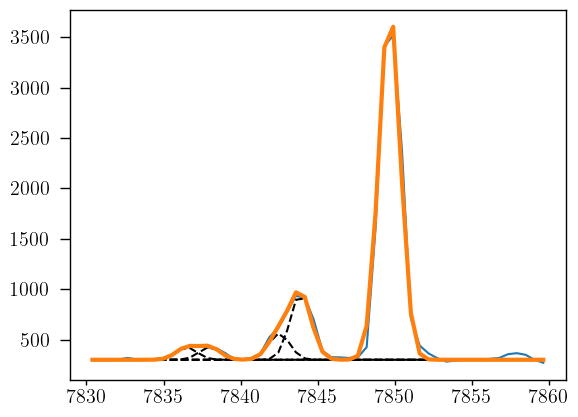

In [226]:
arc1_7135 = out_arc_7135.flatchain.arc1.mean()
arc2_7135 = out_arc_7135.flatchain.arc2.mean()
arc3_7135 = out_arc_7135.flatchain.arc3.mean()
arc4_7135 = out_arc_7135.flatchain.arc4.mean()
arc5_7135 = out_arc_7135.flatchain.arc5.mean()
sigma_arc_7135 = out_arc_7135.flatchain.sigma.mean()

plt.plot(x_arc_7135, y_arc_7135)

plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135, arc1_7135,  7836.5, 0, sigma_arc_7135), ls='--', color='black')
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135, arc2_7135,    7838, 0, sigma_arc_7135), ls='--', color='black')
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135, arc3_7135,  7842.5, 0, sigma_arc_7135), ls='--', color='black')
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135, arc4_7135,  7843.9, 0, sigma_arc_7135), ls='--', color='black')
plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135, arc5_7135, 7849.67, 0, sigma_arc_7135), ls='--', color='black')

plt.plot(x_arc_7135, 300 + gaussian(x_arc_7135, arc1_7135,  7836.5, 0, sigma_arc_7135) \
                         + gaussian(x_arc_7135, arc2_7135,    7838, 0, sigma_arc_7135) \
                         + gaussian(x_arc_7135, arc3_7135,  7842.5, 0, sigma_arc_7135) \
                         + gaussian(x_arc_7135, arc4_7135,  7843.9, 0, sigma_arc_7135) \
                         + gaussian(x_arc_7135, arc5_7135, 7849.67, 0, sigma_arc_7135), lw=3
)

# [OIII]5007 + HeI 5015

### Arc lines

In [234]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_5007 = [wave_cat['[OIII]5007']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]5007']*(1 + z_BN[igal]) + 10]
mask_arc_5007 = (wcal_red[8].data['wave_soln'][0] >= wlims_5007[0]) & (wcal_red[8].data['wave_soln'][0] < wlims_5007[1])

# Arc spectra around the fitted line
x_arc_5007 = wcal_red[8].data['wave_soln'][0][mask_arc_5007]
y_arc_5007 = wcal_red[21].data[:, 3][mask_arc_5007]

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 108.16it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 27.88888667  36.4387168   64.19976547 118.21808815  69.51913566]


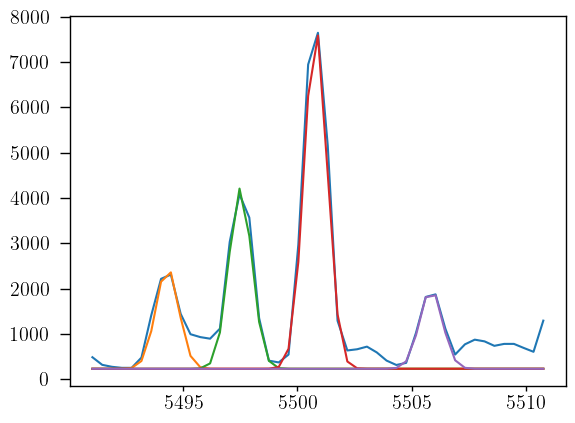

In [235]:
plt.plot(x_arc_5007, y_arc_5007)
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, 2800, 5494.3, 0, 0.5))
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, 5000, 5497.5, 0, 0.5))
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, 9400, 5500.8, 0, 0.5))
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, 2200, 5505.85, 0, 0.5))

params_arc_5007 = Parameters()
params_arc_5007.add('z', value=0.0, vary=False)
params_arc_5007.add('mu1', value=5494.3, vary=False)
params_arc_5007.add('mu2', value=5497.5, vary=False)
params_arc_5007.add('mu3', value=5500.8, vary=False)
params_arc_5007.add('mu4', value=5505.85, vary=False)
params_arc_5007.add('arc1', value=2800, min=0.)
params_arc_5007.add('arc2', value=5000, min=0.)
params_arc_5007.add('arc3', value=9400, min=0.)
params_arc_5007.add('arc4', value=2200, min=0.)
params_arc_5007.add('sigma', value=0.5, min=0.)
params_arc_5007.add('bkg', value=230, vary=False)

def residual_arc_5007(params_arc_5007, x, data, uncertainty):
    
    z = params_arc_5007['z']
    mu1 = params_arc_5007['mu1']
    mu2 = params_arc_5007['mu2']
    mu3 = params_arc_5007['mu3']
    mu4 = params_arc_5007['mu4']
    flux1 = params_arc_5007['arc1']
    flux2 = params_arc_5007['arc2']
    flux3 = params_arc_5007['arc3']
    flux4 = params_arc_5007['arc4']
    sigma = params_arc_5007['sigma']
    bkg = params_arc_5007['bkg']
    
    x = x_arc_5007
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_5007) / 10

np.random.seed(21)
out_arc_5007 = minimize(residual_arc_5007, params_arc_5007, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

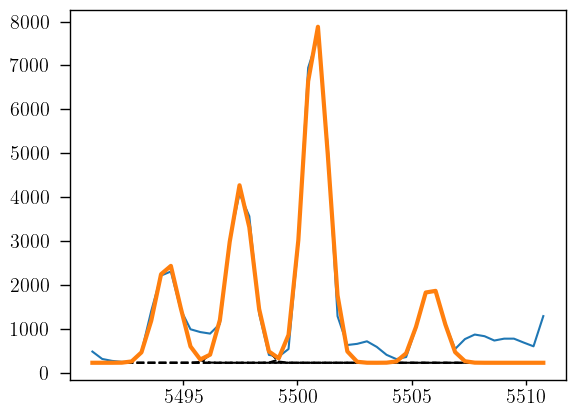

In [236]:
arc1_5007 = out_arc_5007.flatchain.arc1.mean()
arc2_5007 = out_arc_5007.flatchain.arc2.mean()
arc3_5007 = out_arc_5007.flatchain.arc3.mean()
arc4_5007 = out_arc_5007.flatchain.arc4.mean()
sigma_arc_5007 = out_arc_5007.flatchain.sigma.mean()

plt.plot(x_arc_5007, y_arc_5007)

plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc1_5007, 5494.3, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc2_5007, 5497.5, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc3_5007, 5500.8, 0, sigma_arc_5007), ls='--', color='black')
plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc4_5007, 5505.85, 0, sigma_arc_5007), ls='--', color='black')

plt.plot(x_arc_5007, 230 + gaussian(x_arc_5007, arc1_5007, 5494.3, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc2_5007, 5497.5, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc3_5007, 5500.8, 0, sigma_arc_5007) \
         + gaussian(x_arc_5007, arc4_5007, 5505.85, 0, sigma_arc_5007), lw=3
)

# [FeIII]4658

### Arc lines

In [246]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4658 = [wave_cat['[FeIII]4658']*(1 + z_BN[igal]) - 10, wave_cat['[FeIII]4658']*(1 + z_BN[igal]) + 10]
mask_arc_4658 = (wcal_red[6].data['wave_soln'][0] >= wlims_4658[0]) & (wcal_red[6].data['wave_soln'][0] < wlims_4658[1])

# Arc spectra around the fitted line
x_arc_4658 = wcal_red[6].data['wave_soln'][0][mask_arc_4658]
y_arc_4658 = wcal_red[21].data[:, 2][mask_arc_4658]

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 107.13it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [46.66871902 43.57888171 45.98270948 68.31520227 58.78724121]


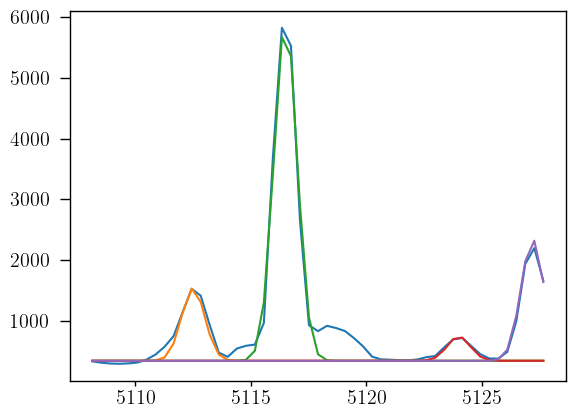

In [247]:
plt.plot(x_arc_4658, y_arc_4658)
plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658, 1500, 5112.5, 0, 0.5))
plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658, 7000, 5116.5, 0, 0.5))
plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658,  500,   5124, 0, 0.5))
plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658, 2500, 5127.2, 0, 0.5))

params_arc_4658 = Parameters()
params_arc_4658.add('z', value=0.0, vary=False)
params_arc_4658.add('mu1', value=5112.5, vary=False)
params_arc_4658.add('mu2', value=5116.5, vary=False)
params_arc_4658.add('mu3', value=  5124, vary=False)
params_arc_4658.add('mu4', value=5127.2, vary=False)
params_arc_4658.add('arc1', value=1500, min=0.)
params_arc_4658.add('arc2', value=7000, min=0.)
params_arc_4658.add('arc3', value= 500, min=0.)
params_arc_4658.add('arc4', value=2500, min=0.)
params_arc_4658.add('sigma', value=0.5, min=0.)
params_arc_4658.add('bkg', value=350, vary=False)

def residual_arc_4658(params_arc_4658, x, data, uncertainty):
    
    z = params_arc_4658['z']
    mu1 = params_arc_4658['mu1']
    mu2 = params_arc_4658['mu2']
    mu3 = params_arc_4658['mu3']
    mu4 = params_arc_4658['mu4']
    flux1 = params_arc_4658['arc1']
    flux2 = params_arc_4658['arc2']
    flux3 = params_arc_4658['arc3']
    flux4 = params_arc_4658['arc4']
    sigma = params_arc_4658['sigma']
    bkg = params_arc_4658['bkg']
    
    x = x_arc_4658
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model4 = gaussian(x, flux4, mu4, z, sigma)
    model = bkg + model1 + model2 + model3 + model4
    return (model - y_arc_4658) / 10

np.random.seed(21)
out_arc_4658 = minimize(residual_arc_4658, params_arc_4658, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

In [248]:
out_arc_4658.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,5112.50000,,,5112.5,-inf,inf,False
mu2,5116.50000,,,5116.5,-inf,inf,False
mu3,5124.00000,,,5124,-inf,inf,False
mu4,5127.20000,,,5127.2,-inf,inf,False
arc1,1571.91876,8.07229021,(0.51%),1500,0.00000000,inf,True
arc2,7048.88104,9.99380457,(0.14%),7000,0.00000000,inf,True
arc3,508.784969,8.42194677,(1.66%),500,0.00000000,inf,True
arc4,2359.00884,8.55232622,(0.36%),2500,0.00000000,inf,True
sigma,0.48551302,7.7988e-04,(0.16%),0.5,0.00000000,inf,True


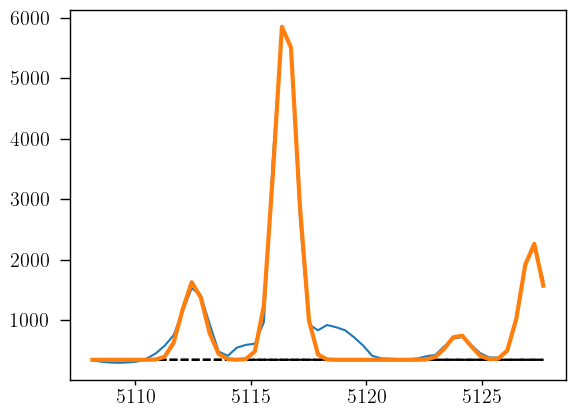

In [249]:
arc1_4658 = out_arc_4658.flatchain.arc1.mean()
arc2_4658 = out_arc_4658.flatchain.arc2.mean()
arc3_4658 = out_arc_4658.flatchain.arc3.mean()
arc4_4658 = out_arc_4658.flatchain.arc4.mean()
sigma_arc_4658 = out_arc_4658.flatchain.sigma.mean()

plt.plot(x_arc_4658, y_arc_4658)

plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658, arc1_4658, 5112.5, 0, sigma_arc_4658), ls='--', color='black')
plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658, arc2_4658, 5116.5, 0, sigma_arc_4658), ls='--', color='black')
plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658, arc3_4658,   5124, 0, sigma_arc_4658), ls='--', color='black')
plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658, arc4_4658, 5127.2, 0, sigma_arc_4658), ls='--', color='black')

plt.plot(x_arc_4658, 350 + gaussian(x_arc_4658, arc1_4658, 5112.5, 0, sigma_arc_4658) \
                         + gaussian(x_arc_4658, arc2_4658, 5116.5, 0, sigma_arc_4658) \
                         + gaussian(x_arc_4658, arc3_4658,   5124, 0, sigma_arc_4658) \
                         + gaussian(x_arc_4658, arc4_4658, 5127.2, 0, sigma_arc_4658), lw=3
)

# [OIII]4363

### Arc lines

In [257]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_4363 = [wave_cat['[OIII]4363']*(1 + z_BN[igal]) - 10, wave_cat['[OIII]4363']*(1 + z_BN[igal])]
mask_arc_4363 = (wcal_blue[10].data['wave_soln'][0] >= wlims_4363[0]) & (wcal_blue[10].data['wave_soln'][0] < wlims_4363[1])

# Arc spectra around the fitted line
x_arc_4363 = wcal_blue[10].data['wave_soln'][0][mask_arc_4363]
y_arc_4363 = wcal_blue[27].data[:, 4][mask_arc_4363]

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 124.67it/s]


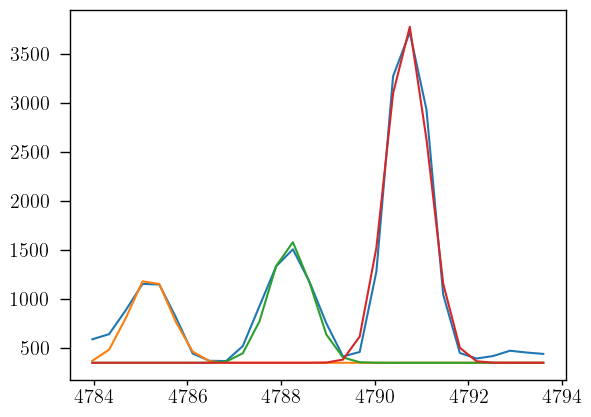

In [258]:
plt.plot(x_arc_4363, y_arc_4363)
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, 1000, 4785.2, 0, 0.45))
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, 1400, 4788.2, 0, 0.45))
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, 3900, 4790.7, 0, 0.45))

params_arc_4363 = Parameters()
params_arc_4363.add('z', value=0.0, vary=False)
params_arc_4363.add('mu1', value=4785.2, vary=False)
params_arc_4363.add('mu2', value=4788.2, vary=False)
params_arc_4363.add('mu3', value=4790.7, vary=False)
params_arc_4363.add('arc1', value=1000, min=0.)
params_arc_4363.add('arc2', value=1400, min=0.)
params_arc_4363.add('arc3', value=3900, min=0.)
params_arc_4363.add('sigma', value=0.45, min=0.)
params_arc_4363.add('bkg', value=350, vary=False)

def residual_arc_4363(params_arc_4363, x, data, uncertainty):
    
    z = params_arc_4363['z']
    mu1 = params_arc_4363['mu1']
    mu2 = params_arc_4363['mu2']
    mu3 = params_arc_4363['mu3']
    flux1 = params_arc_4363['arc1']
    flux2 = params_arc_4363['arc2']
    flux3 = params_arc_4363['arc3']
    sigma = params_arc_4363['sigma']
    bkg = params_arc_4363['bkg']
    
    x = x_arc_4363
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_4363) / 10

np.random.seed(21)
out_arc_4363 = minimize(residual_arc_4363, params_arc_4363, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

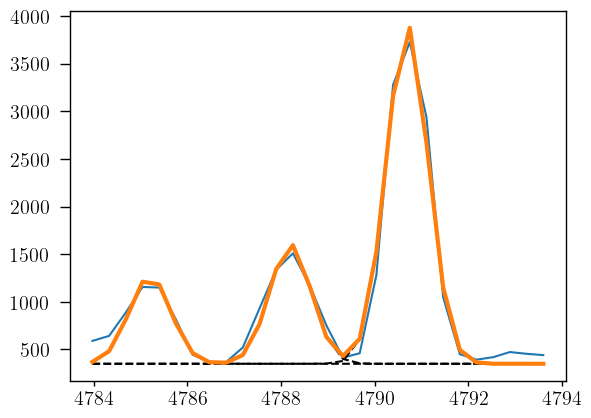

In [259]:
arc1_4363 = out_arc_4363.flatchain.arc1.mean()
arc2_4363 = out_arc_4363.flatchain.arc2.mean()
arc3_4363 = out_arc_4363.flatchain.arc3.mean()
sigma_arc_4363 = out_arc_4363.flatchain.sigma.mean()

plt.plot(x_arc_4363, y_arc_4363)

plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, arc1_4363, 4785.2, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, arc2_4363, 4788.2, 0, sigma_arc_4363), ls='--', color='black')
plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, arc3_4363, 4790.7, 0, sigma_arc_4363), ls='--', color='black')

plt.plot(x_arc_4363, 350 + gaussian(x_arc_4363, arc1_4363, 4785.2, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc2_4363, 4788.2, 0, sigma_arc_4363) \
         + gaussian(x_arc_4363, arc3_4363, 4790.7, 0, sigma_arc_4363), lw=3
)

# [NeIII]3686

### Arc lines

In [269]:
# Select a region of the arc spectra to have a few arc lines around the wavelength of the fitted lines
wlims_3868 = [wave_cat['[NeIII]3868']*(1 + z_BN[igal]) - 5, wave_cat['[NeIII]3868']*(1 + z_BN[igal]) + 5]
mask_arc_3868 = (wcal_blue[8].data['wave_soln'][0] >= wlims_3868[0]) & (wcal_blue[8].data['wave_soln'][0] < wlims_3868[1])

# Arc spectra around the fitted line
x_arc_3868 = wcal_blue[8].data['wave_soln'][0][mask_arc_3868]
y_arc_3868 = wcal_blue[27].data[:, 3][mask_arc_3868]

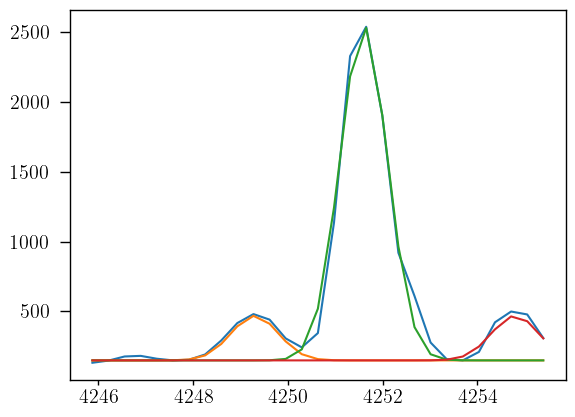

In [270]:
plt.plot(x_arc_3868, y_arc_3868)
plt.plot(x_arc_3868, 150 + gaussian(x_arc_3868,  400, 4249.3, 0, 0.5))
plt.plot(x_arc_3868, 150 + gaussian(x_arc_3868, 3000, 4251.6, 0, 0.5))
plt.plot(x_arc_3868, 150 + gaussian(x_arc_3868,  400, 4254.8, 0, 0.5))

In [271]:
params_arc_3868 = Parameters()
params_arc_3868.add('z', value=0.0, vary=False)
params_arc_3868.add('mu1', value=4249.3, vary=False)
params_arc_3868.add('mu2', value=4251.6, vary=False)
params_arc_3868.add('mu3', value=4254.8, vary=False)
params_arc_3868.add('arc1', value= 400, min=0.)
params_arc_3868.add('arc2', value=3000, min=0.)
params_arc_3868.add('arc3', value= 400, min=0.)
params_arc_3868.add('sigma', value=0.45, min=0.)
params_arc_3868.add('bkg', value=150, vary=False)

def residual_arc_3868(params_arc_3868, x, data, uncertainty):
    
    z = params_arc_3868['z']
    mu1 = params_arc_3868['mu1']
    mu2 = params_arc_3868['mu2']
    mu3 = params_arc_3868['mu3']
    flux1 = params_arc_3868['arc1']
    flux2 = params_arc_3868['arc2']
    flux3 = params_arc_3868['arc3']
    sigma = params_arc_3868['sigma']
    bkg = params_arc_3868['bkg']
    
    x = x_arc_3868
    model1 = gaussian(x, flux1, mu1, z, sigma)
    model2 = gaussian(x, flux2, mu2, z, sigma)
    model3 = gaussian(x, flux3, mu3, z, sigma)
    model = bkg + model1 + model2 + model3
    return (model - y_arc_3868) / 10

np.random.seed(21)
out_arc_3868 = minimize(residual_arc_3868, params_arc_3868, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:20<00:00, 120.92it/s]


In [272]:
out_arc_3868.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.00000000,,,0.0,-inf,inf,False
mu1,4249.30000,,,4249.3,-inf,inf,False
mu2,4251.60000,,,4251.6,-inf,inf,False
mu3,4254.80000,,,4254.8,-inf,inf,False
arc1,423.566141,7.60328609,(1.80%),400,0.00000000,inf,True
arc2,2977.40578,9.30936338,(0.31%),3000,0.00000000,inf,True
arc3,440.999839,7.80411815,(1.77%),400,0.00000000,inf,True
sigma,0.48306492,0.00171880,(0.36%),0.45,0.00000000,inf,True
bkg,150.000000,,,150,-inf,inf,False


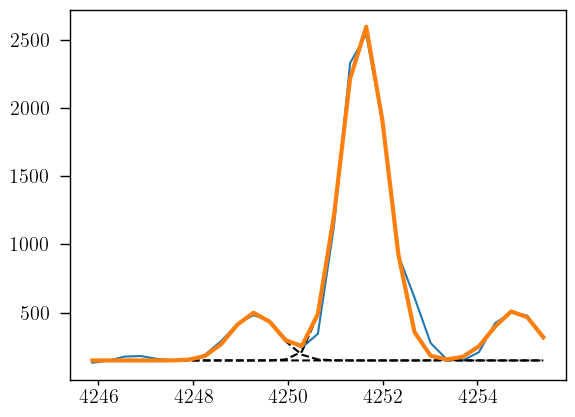

In [273]:
arc1_3868 = out_arc_3868.flatchain.arc1.mean()
arc2_3868 = out_arc_3868.flatchain.arc2.mean()
arc3_3868 = out_arc_3868.flatchain.arc3.mean()
sigma_arc_3868 = out_arc_3868.flatchain.sigma.mean()

plt.plot(x_arc_3868, y_arc_3868)

plt.plot(x_arc_3868, 150 + gaussian(x_arc_3868, arc1_3868, 4249.3, 0, sigma_arc_3868), ls='--', color='black')
plt.plot(x_arc_3868, 150 + gaussian(x_arc_3868, arc2_3868, 4251.6, 0, sigma_arc_3868), ls='--', color='black')
plt.plot(x_arc_3868, 150 + gaussian(x_arc_3868, arc3_3868, 4254.8, 0, sigma_arc_3868), ls='--', color='black')

plt.plot(x_arc_3868, 150 + gaussian(x_arc_3868, arc1_3868, 4249.3, 0, sigma_arc_3868) \
                         + gaussian(x_arc_3868, arc2_3868, 4251.6, 0, sigma_arc_3868) \
                         + gaussian(x_arc_3868, arc3_3868, 4254.8, 0, sigma_arc_3868), lw=3
)

# Saving arc data

In [285]:
wave_cat

{'[SIII]9532': 9531.1,
 '[SIII]9069': 9068.6,
 'P11': 8862.89,
 'P12': 8750.46,
 'P13': 8665.02,
 'P14': 8598.39,
 'P15': 8545.38,
 'P16': 8502.49,
 'P17': 8467.26,
 '[OI]8446': 8446.36,
 'P18': 8437.95,
 'P19': 8413.32,
 '[ArIII]7751': 7751.06,
 '[OII]7330': 7330.19,
 '[OII]7319': 7319.92,
 'HeI7281': 7281.349,
 '[ArIII]7135': 7135.8,
 'HeI7065': 7065.19,
 '[SII]6730': 6730.815,
 '[SII]6716': 6716.44,
 'HeI6678': 6678.151,
 '[NII]6584': 6583.45,
 'Ha': 6562.79,
 '[NII]6548': 6548.05,
 '[OI]6363': 6363.776,
 '[SIII]6312': 6312.06,
 '[OI]6300': 6300.304,
 'HeI5875': 5875.621,
 '[NII]5755': 5754.59,
 'HeI5015': 5015.6783,
 '[OIII]5007': 5006.843,
 '[FeIII]4985': 4985.86,
 '[OIII]4959': 4958.911,
 '4921': 4921.8,
 'Hb': 4861.35,
 '[ArIV]4740': 4740.2,
 '[ArIV]4711': 4711.35,
 'HeII4685': 4685.71,
 '[FeIII]4658': 4658.05,
 'HeI4471': 4471.4802,
 'HeI4388': 4387.9296,
 '[OIII]4363': 4363.209,
 '[FeII]4360': 4359.332,
 'Hg': 4340.472,
 'Hd': 4101.710277,
 '[SII]4076': 4076.349,
 '[SII]4068':

In [286]:
sigma_arc = np.array([sigma_arc_3729,
                      sigma_arc_3868,
                      sigma_arc_hd,
                      sigma_arc_hg,
                      sigma_arc_4363,
                      sigma_arc_4471,
                      sigma_arc_4658,
                      sigma_arc_4685,
                      sigma_arc_hb,
                      sigma_arc_4959,
                      sigma_arc_5007,
                      sigma_arc_5755,
                      sigma_arc_5875,
                      sigma_arc_6312,
                      sigma_arc_ha,
                      sigma_arc_6678,
                      sigma_arc_6730,
                      sigma_arc_7065,
                      sigma_arc_7135,
                      sigma_arc_7330,
                      sigma_arc_9069,
                      sigma_arc_9532])

x_arc = np.array([np.median(x_arc_3729),
                  np.median(x_arc_3868),
                  np.median(x_arc_hd),
                  np.median(x_arc_hg),
                  np.median(x_arc_4363),
                  np.median(x_arc_4471),
                  np.median(x_arc_4658),
                  np.median(x_arc_4685),
                  np.median(x_arc_hb),
                  np.median(x_arc_4959),
                  np.median(x_arc_5007),
                  np.median(x_arc_5755),
                  np.median(x_arc_5875),
                  np.median(x_arc_6312),
                  np.median(x_arc_ha),
                  np.median(x_arc_6678),
                  np.median(x_arc_6730),
                  np.median(x_arc_7065),
                  np.median(x_arc_7135),
                  np.median(x_arc_7330),
                  np.median(x_arc_9069),
                  np.median(x_arc_9532)])

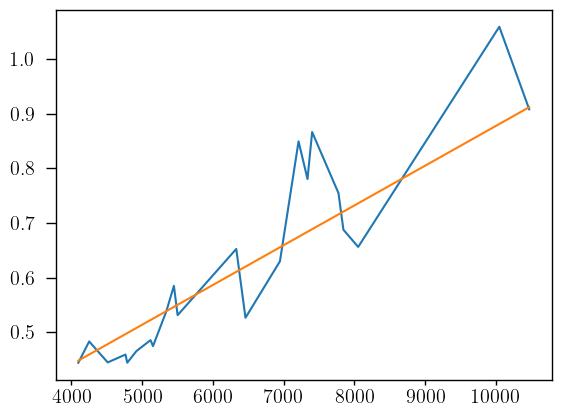

In [287]:
plt.plot(x_arc, sigma_arc)
plt.plot(x_arc, (((sigma_arc[-1] - sigma_arc[0])/(x_arc[-1] - x_arc[0])) * x_arc) + 0.15)

In [288]:
params_sigma_arc = Parameters()
params_sigma_arc.add('m', value=(sigma_arc[-1] - sigma_arc[0])/(x_arc[-1] - x_arc[0]))
params_sigma_arc.add('n', value=0.15)

def residual_sigma_arc(params_sigma_arc, x, data, uncertainty):
    
    m = params_sigma_arc['m']
    n = params_sigma_arc['n']
    
    x = x_arc
    model = (m * x_arc) + n
    return (model - sigma_arc) / 0.05

np.random.seed(136)
out_sigma_arc = minimize(residual_sigma_arc, params_sigma_arc, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:10<00:00, 245.65it/s]


In [289]:
lmfit.report_fit(out_sigma_arc.params)

[[Variables]]
    m:  9.1260e-05 +/- 6.2198e-06 (6.82%) (init = 7.274864e-05)
    n:  0.04415798 +/- 0.04068564 (92.14%) (init = 0.15)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, n) = -0.9660


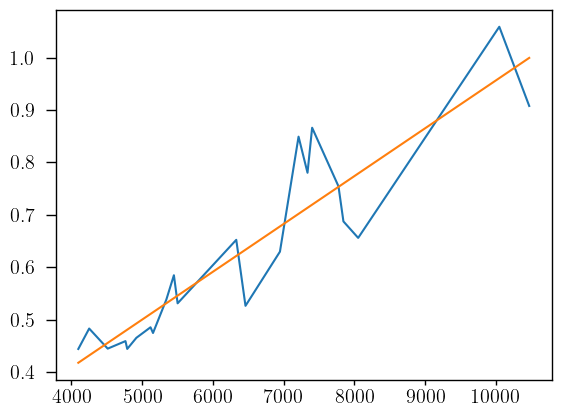

In [290]:
m = out_sigma_arc.flatchain.m.mean()
n = out_sigma_arc.flatchain.n.mean()

plt.plot(x_arc, sigma_arc)
plt.plot(x_arc, (m * x_arc) + n)